### CODE FOR COMBINING ALL EXCEL FILES

In [23]:
import pandas as pd
import os
from pathlib import Path

# 1. Set your path
current_directory = '/Users/noshin/Desktop/Dr.Khalid/All Results/DFS'

# 2. Find any files containing 'our_generator' (CSV or Excel)
# Changed filter from 'cery_machines' to 'our_generator'
files = [
    f for f in os.listdir(current_directory) 
    if 'our_generator' in f.lower() and (f.endswith('.xlsx') or f.endswith('.csv'))
]

print(f"Files found: {files}")

df_list = []
for file in files:
    file_path = os.path.join(current_directory, file)
    try:
        # Detect file type and read
        if file.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)
        
        # Clean column names in case of leading/trailing spaces
        df.columns = [c.strip() for c in df.columns]
        
        df_list.append(df)
        print(f"Successfully loaded: {file}")
    except Exception as e:
        print(f"Could not read {file}: {e}")

# 3. Combine and Sort
if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # Ensure 'Number of Mutants' is treated as a number for correct sorting
    column_name = 'Number of Mutants'
    if column_name in combined_df.columns:
        combined_df[column_name] = pd.to_numeric(combined_df[column_name], errors='coerce')
        combined_df = combined_df.dropna(subset=[column_name])
        combined_df_sorted = combined_df.sort_values(by=column_name, ascending=True)
        print(f"Sorted by {column_name} (Ascending)")
    else:
        print(f"Warning: Column '{column_name}' not found. Saving unsorted.")
        combined_df_sorted = combined_df

    # 4. Save to Excel
    output_path = os.path.join(current_directory, 'combined_our_generator_results.xlsx')
    combined_df_sorted.to_excel(output_path, index=False)
    
    print(f"\nSuccess! Combined {len(df_list)} files.")
    print(f"Final file saved at: {output_path}")
else:
    print("\nNo matching files found with 'our_generator' in the name.")

Files found: ['DFS_results_128state_fsms_complete_100000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_30000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_10000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_50000_our_generator.xlsx']
Successfully loaded: DFS_results_128state_fsms_complete_100000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_30000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_10000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_50000_our_generator.xlsx
Sorted by Number of Mutants (Ascending)

Success! Combined 4 files.
Final file saved at: /Users/noshin/Desktop/Dr.Khalid/All Results/DFS/combined_our_generator_results.xlsx


### CERY MACHINES

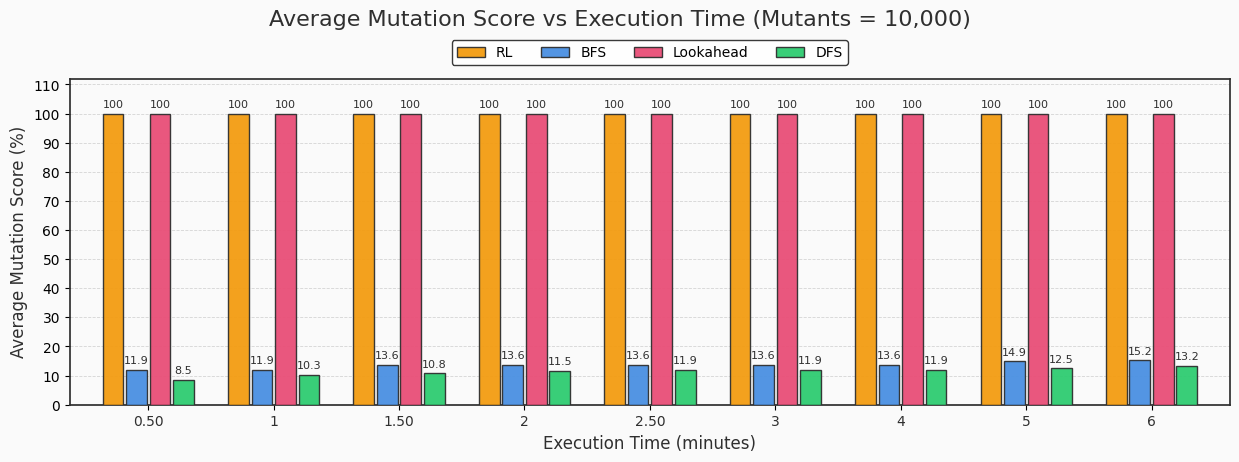

Saved: /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_mutation_vs_time_bar_10000.png


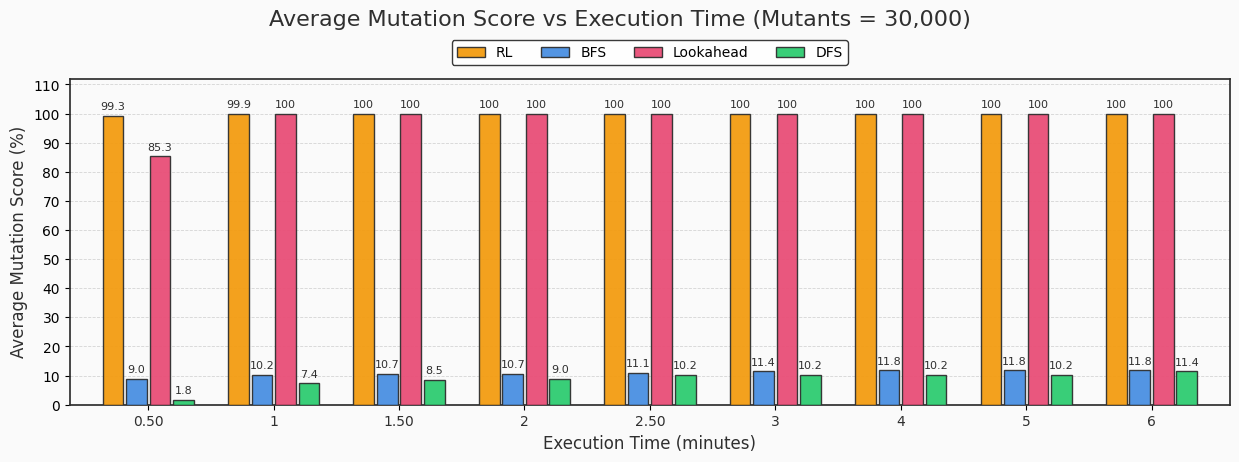

Saved: /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_mutation_vs_time_bar_30000.png


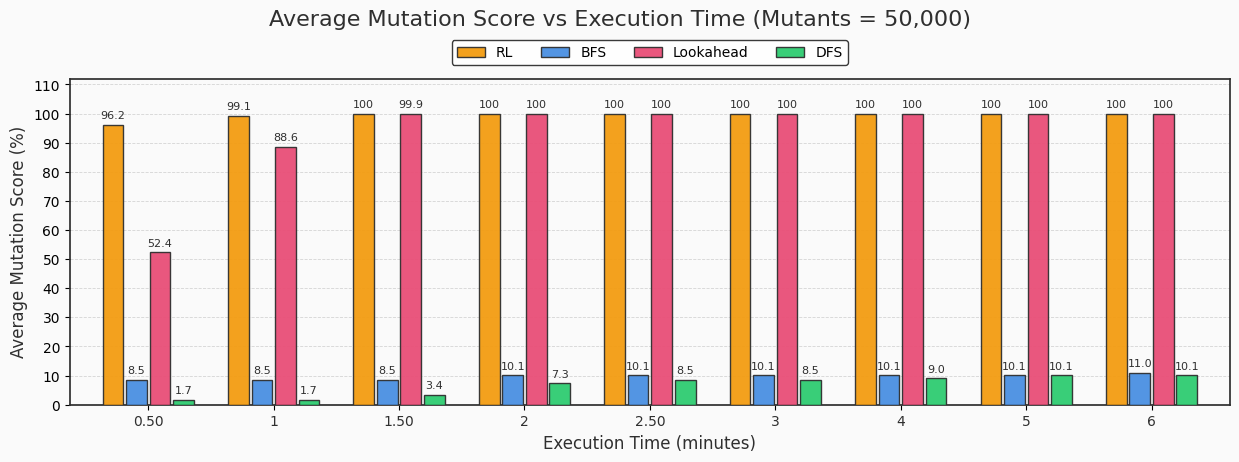

Saved: /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_mutation_vs_time_bar_50000.png


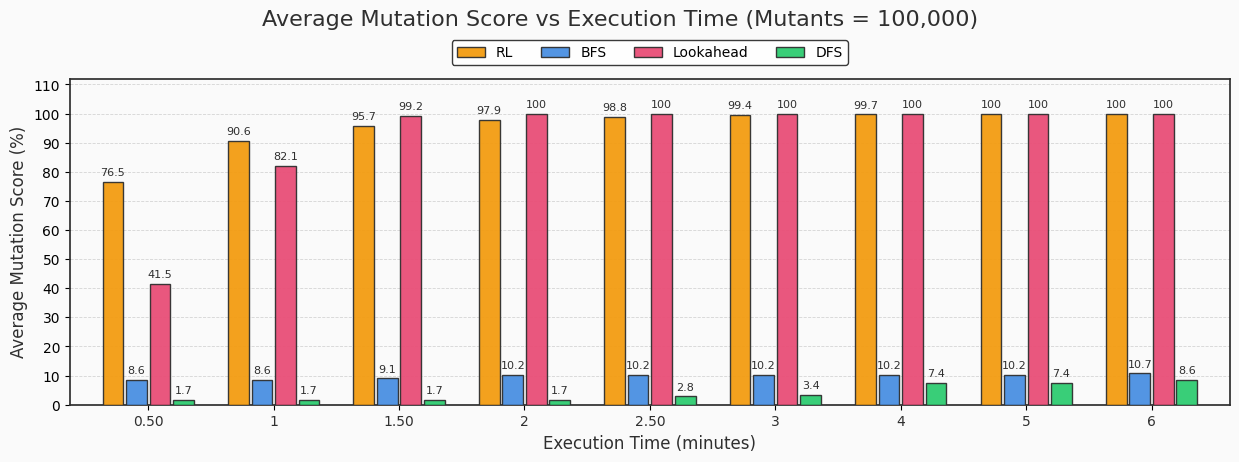

Saved: /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_mutation_vs_time_bar_100000.png


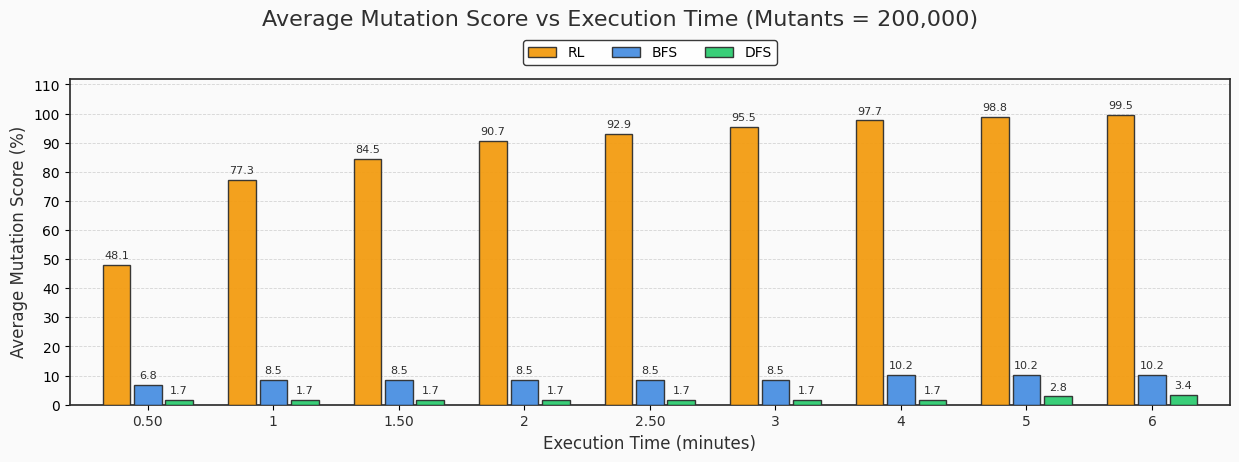

Saved: /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_mutation_vs_time_bar_200000.png


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ===================== PATH =====================
base_dir = Path('/Users/noshin/Desktop/Dr.Khalid/Cery results')

bnb_path = base_dir / "All_BnB_results_cery.xlsx"
rl_path  = base_dir / "All_RL_results_cery.xlsx"
bfs_path = base_dir / "Combined_BFS_4n.xlsx"
dfs_path = base_dir / "Combined_DFS_4n.xlsx"

# ===================== LOAD =====================
bnb_df = pd.read_excel(bnb_path); bnb_df["Method"] = "Lookahead"
rl_df  = pd.read_excel(rl_path);  rl_df["Method"]  = "RL"
bfs_df = pd.read_excel(bfs_path); bfs_df["Method"] = "BFS"
dfs_df = pd.read_excel(dfs_path); dfs_df["Method"] = "DFS"

df = pd.concat([bnb_df, rl_df, bfs_df, dfs_df], ignore_index=True)

# Normalize "Number of Mutants" column name if needed
if "Number of Mutants" not in df.columns:
    for c in df.columns:
        if "Mutant" in c and "Number" in c:
            df.rename(columns={c: "Number of Mutants"}, inplace=True)
            break

# ===================== TIME COLUMN PARSING =====================
score_cols = [c for c in df.columns if re.match(r"^Mutation Score after .* \(%\)$", c)]

def parse_time_to_min(label: str) -> float:
    m = re.search(r"after (.+) \(%\)$", label)
    if not m:
        return None
    t = m.group(1)
    mins = 0.0
    m_min = re.search(r"(\d+)\s*min", t)
    m_sec = re.search(r"(\d+)\s*s", t)
    if m_min:
        mins += float(m_min.group(1))
    if m_sec:
        mins += float(m_sec.group(1)) / 60.0
    if not m_min and not m_sec:
        try:
            mins = float(t)
        except:
            return None
    return mins

time_map = {col: parse_time_to_min(col) for col in score_cols if parse_time_to_min(col) is not None}

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"

# NEW: Updated vibrant, distinct color palette
COLORS = {
    "RL": "#F39C12", # Deep Gold
    "BFS": "#4A90E2", # Professional Blue
    "Lookahead": "#E94E77", # Soft Crimson
    "DFS": "#2ECC71", # Bright Green
}

GROUP_WIDTH = 0.75
ANNOTATE_EVERY = 1

ORDERED_MUTANTS = [10000, 30000, 50000, 100000, 200000]
present_mutants = [m for m in ORDERED_MUTANTS if (df["Number of Mutants"] == m).any()]
if not present_mutants:
    present_mutants = sorted(df["Number of Mutants"].dropna().unique().tolist())

# ===================== PLOT FUNCTION =====================
def make_bar_plot_for_mutants(mutants_value: int):
    sub = df[df["Number of Mutants"] == mutants_value].copy()
    if sub.empty:
        return

    # Aggregate mean mutation score per (method, time)
    rows = []
    for method in sub["Method"].unique():
        subm = sub[sub["Method"] == method]
        for col, tmin in time_map.items():
            if col in subm.columns:
                rows.append([tmin, method, subm[col].mean(skipna=True)])
    plot_df = pd.DataFrame(rows, columns=["Time (min)", "Method", "Avg Mutation Score (%)"])

    # Pivot to (times x methods)
    pivot_df = plot_df.pivot_table(index="Time (min)", columns="Method",
                                values="Avg Mutation Score (%)").sort_index()

    # Force the bar order: RL first
    METHOD_ORDER = ["RL", "BFS", "Lookahead", "DFS"]
    # Keep only methods that actually exist in the data
    methods = [m for m in METHOD_ORDER if m in pivot_df.columns]
    pivot_df = pivot_df[methods]

    times = pivot_df.index.values
    x = np.arange(len(times))
    n = len(methods)
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    
    # === CHANGED LINE: Added axis='y' to only show horizontal grid lines ===
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    # === HEADER ===
    fig.suptitle(f"Average Mutation Score vs Execution Time (Mutants = {mutants_value:,})",
                 fontsize=16, color=EDGE, y = 0.88, x = 0.5)

    # === BARS ===
    for i, method in enumerate(methods):
        y = pivot_df[method].values
        positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

        bars = ax.bar(
            positions, y,
            width=bar_width * 0.88,
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3
        )

        # value labels
        for j, b in enumerate(bars):
            if (j % ANNOTATE_EVERY) != 0:
                continue
            h = b.get_height()
            
            text_val = "100" if h >= 99.9 else f"{h:.1f}"
            
            ax.text(b.get_x() + b.get_width()/2, h + 1.5, text_val,
                    ha="center", va="bottom", fontsize=8, color=EDGE)

    # ticks centered under each group
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(t)}" if float(t).is_integer() else f"{t:.2f}" for t in times],
                       fontsize=10, color=EDGE)

    # axes labels & limits
    ax.set_xlabel("Execution Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Mutation Score (%)", fontsize=12, color=EDGE)
    ax.set_yticks(np.arange(0, 111, 10))
    ax.set_ylim(0, 112)

    # frame
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # legend
    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),  
        ncol=n,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = base_dir / f"avg_mutation_vs_time_bar_{mutants_value}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

# ===================== RUN =====================
for m in present_mutants:
    make_bar_plot_for_mutants(m)

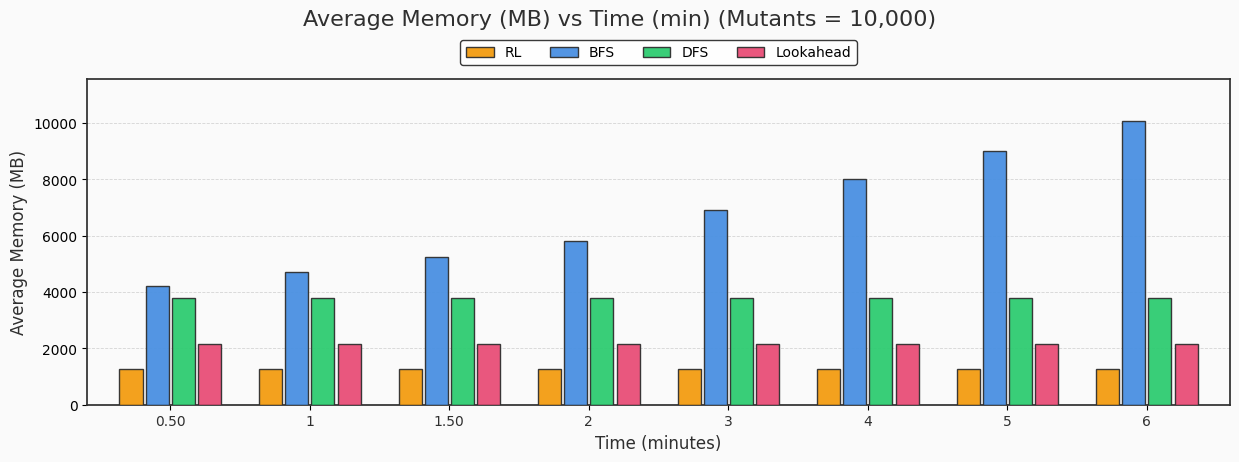

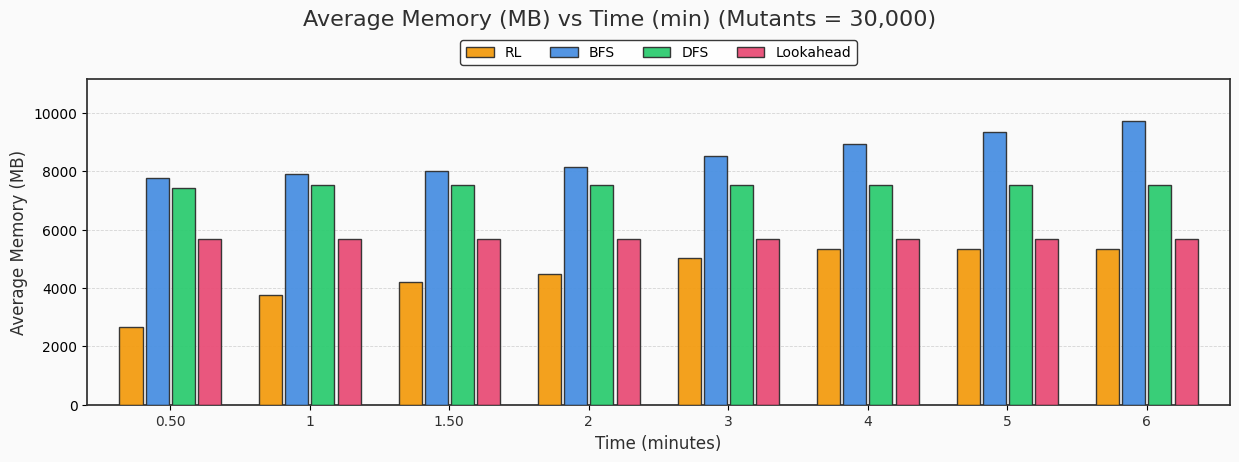

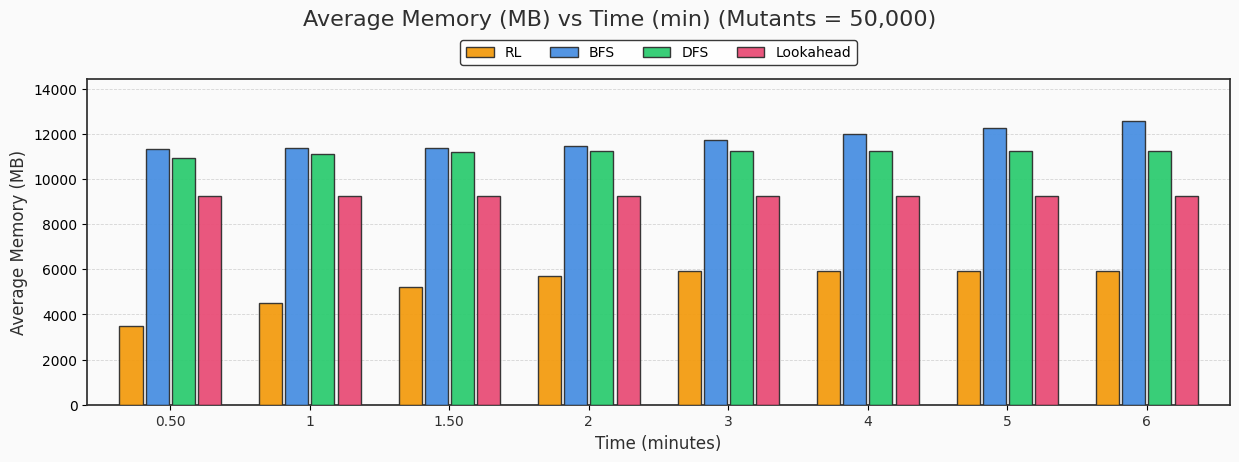

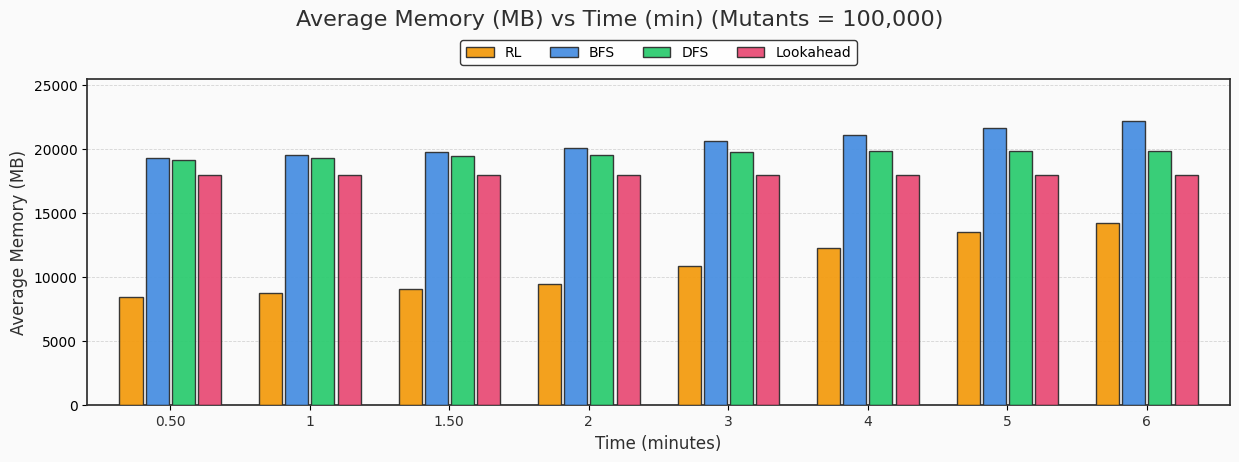

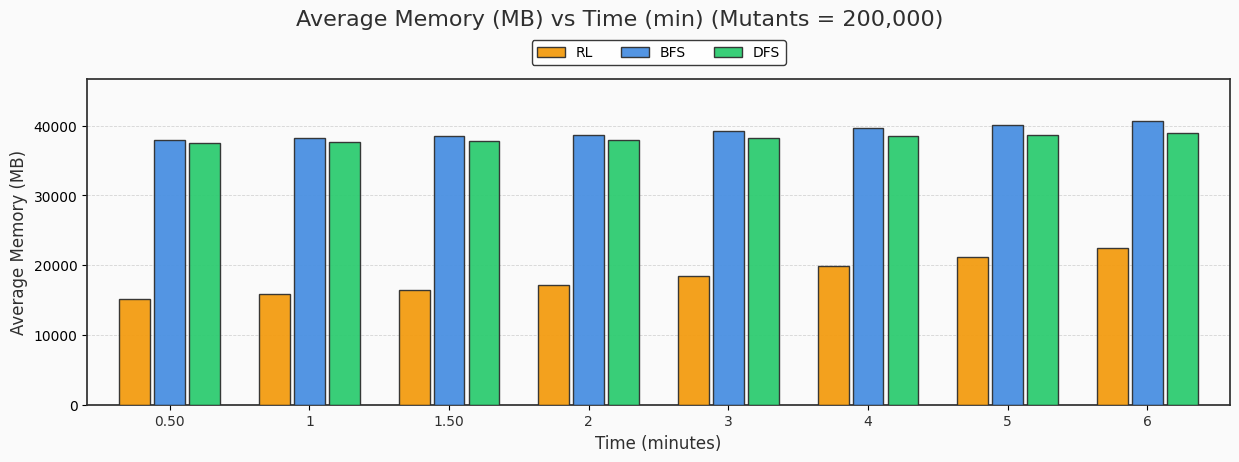

Saved figures:
- /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_memory_vs_time_bar_10000.png
- /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_memory_vs_time_bar_30000.png
- /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_memory_vs_time_bar_50000.png
- /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_memory_vs_time_bar_100000.png
- /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_memory_vs_time_bar_200000.png
Saved data table: /Users/noshin/Desktop/Dr.Khalid/Cery results/avg_memory_vs_time_agg.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from typing import Optional, Union

# ===================== PATH =====================
base_dir = Path("/Users/noshin/Desktop/Dr.Khalid/Cery results")

bnb_path = base_dir / "All_BnB_results_cery.xlsx"
rl_path  = base_dir / "All_RL_results_cery.xlsx"
bfs_path = base_dir / "Combined_BFS_4n.xlsx"
dfs_path = base_dir / "Combined_DFS_4n.xlsx"

# ===================== LOAD =====================
def load_with_method(path: Path, method: str) -> pd.DataFrame:
    try:
        xl = pd.ExcelFile(path)
        frames = []
        for sh in xl.sheet_names:
            df = xl.parse(sh)
            df["__sheet__"] = sh
            frames.append(df)
        out = pd.concat(frames, ignore_index=True)
        out["Method"] = method
        return out
    except Exception as e:
        print(f"Warning: Could not load {path}. Error: {e}")
        return pd.DataFrame()

# "BnB" is now "Lookahead"
bnb = load_with_method(bnb_path, "Lookahead")
rl  = load_with_method(rl_path, "RL")
bfs = load_with_method(bfs_path, "BFS")
dfs = load_with_method(dfs_path, "DFS")

df = pd.concat([bnb, rl, bfs, dfs], ignore_index=True)

if df.empty:
    print("Error: No data loaded. Check paths.")
    exit()

# ===================== NORMALIZE "Number of Mutants" =====================
mut_col = None
for c in df.columns:
    cl = str(c).strip().lower()
    if ("mutant" in cl) and ("number" in cl or "count" in cl or cl in {"mutants","num_mutants","n_mutants","no. of mutants"}):
        mut_col = c
        break
if mut_col is None and "Number of Mutants" in df.columns:
    mut_col = "Number of Mutants"
if mut_col is None:
    df["Number of Mutants"] = np.nan
else:
    df.rename(columns={mut_col: "Number of Mutants"}, inplace=True)

# ===================== DETECT MEMORY-AT-TIME COLUMNS =====================
def extract_minutes(colname: str) -> Optional[float]:
    s = colname.lower()
    if ("memory" not in s) or ("after" not in s):
        return None
    m_min = re.search(r"(\d+(?:\.\d+)?)\s*min", s)
    m_sec = re.search(r"(\d+(?:\.\d+)?)\s*s(?![a-z])", s)
    found = False
    minutes = 0.0
    if m_min:
        minutes += float(m_min.group(1)); found = True
    if m_sec:
        minutes += float(m_sec.group(1)) / 60.0; found = True
    if not found:
        try:
            minutes = float(re.search(r"(\d+(?:\.\d+)?)", s).group(1))
            found = True
        except Exception:
            return None
    return minutes

mem_time_cols = {}
for c in df.columns:
    t = extract_minutes(str(c))
    if t is not None:
        mem_time_cols[str(c)] = t

# ===================== FIXED TIME GRID & SNAP =====================
FIXED_TIMES = [0.5, 1, 1.5, 2, 3, 4, 5, 6]  # minutes

def snap_to_grid(x: float, grid=FIXED_TIMES, tol=0.251):  # 15s tolerance
    arr = np.asarray(grid, dtype=float)
    i = np.argmin(np.abs(arr - x))
    if abs(arr[i] - x) <= tol:
        return float(arr[i])
    return np.nan

# ===================== LONG-FORM DATA =====================
rows = []
for _, r in df.iterrows():
    for col, t in mem_time_cols.items():
        mem_val = pd.to_numeric(r.get(col, np.nan), errors="coerce")
        if pd.notna(mem_val):
            tfix = snap_to_grid(t)
            if not np.isnan(tfix):
                rows.append([
                    r.get("Method", None),
                    r.get("Number of Mutants", None),
                    tfix,
                    float(mem_val)
                ])

long = pd.DataFrame(rows, columns=["Method", "Number of Mutants", "Time (min)", "Memory (MB)"])
agg = (long.groupby(["Number of Mutants", "Method", "Time (min)"])["Memory (MB)"]
           .mean()
           .reset_index()
           .sort_values(["Number of Mutants", "Method", "Time (min)"]))

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"

COLORS = {
    "BFS": "#4A90E2", 
    "Lookahead": "#E94E77", 
    "DFS": "#2ECC71", 
    "RL":  "#F39C12"  
}

GROUP_WIDTH = 0.75         

# ===================== PLOT (ONE FIGURE PER #MUTANTS) =====================
ORDERED_MUTANTS = [10000, 30000, 50000, 100000, 200000]
present_mutants = [m for m in ORDERED_MUTANTS if (agg["Number of Mutants"] == m).any()]
if not present_mutants:
    present_mutants = sorted(pd.unique(agg["Number of Mutants"].dropna()))

def plot_one_bar(mutants_value: Union[int, float]) -> Optional[Path]:
    sub = agg[agg["Number of Mutants"] == mutants_value]
    if sub.empty: return None

    # Pivot the data to get Times as rows and Methods as columns
    pivot_df = sub.pivot_table(index="Time (min)", columns="Method", values="Memory (MB)").reindex(FIXED_TIMES)

    times = pivot_df.index.values
    x = np.arange(len(times))
    
    # CHANGED: "RL" is now explicitly first in the rendering order
    ordered_methods = ["RL", "BFS", "DFS", "Lookahead"]
    methods = [m for m in ordered_methods if m in pivot_df.columns]
    
    if not methods: 
        methods = list(pivot_df.columns)
        
    n = len(methods)
    if n == 0: return None
    
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    # === HEADER ===
    fig.suptitle(f"Average Memory (MB) vs Time (min) (Mutants = {int(mutants_value):,})",
                 fontsize=16, color=EDGE, y=0.88, x=0.5)

    # === BARS ===
    max_height = 0
    for i, method in enumerate(methods):
        y = pivot_df[method].values
        
        # Track maximum height for setting y-axis limits dynamically
        valid_y = [val for val in y if not np.isnan(val)]
        if valid_y and max(valid_y) > max_height:
            max_height = max(valid_y)

        positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

        ax.bar(
            positions, y,
            width=bar_width * 0.88, # Gap between bars in group
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3
        )

    # === AXES & TICKS ===
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(t)}" if float(t).is_integer() else f"{t:.2f}" for t in times],
                       fontsize=10, color=EDGE)

    ax.set_xlabel("Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Memory (MB)", fontsize=12, color=EDGE)
    
    # Dynamic Y-axis
    ax.set_ylim(0, max_height * 1.15 if max_height > 0 else 100)

    # === FRAME ===
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # === LEGEND ===
    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),  
        ncol=n,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = base_dir / f"avg_memory_vs_time_bar_{int(mutants_value)}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    
    # Shows the plot directly in your Jupyter Notebook
    plt.show() 
    
    return out

# ===================== RUN =====================
saved_paths = []
for m in present_mutants:
    p = plot_one_bar(m)
    if p is not None:
        saved_paths.append(str(p))

print("Saved figures:")
for p in saved_paths:
    print("-", p)

# Export the aggregated table
agg_csv = base_dir / "avg_memory_vs_time_agg.csv"
agg.to_csv(agg_csv, index=False)
print("Saved data table:", agg_csv)

In [ ]:
import pandas as pd
import os
from pathlib import Path

# 1. Set your path
current_directory = '/Users/noshin/Desktop/Dr.Khalid/All Results/DFS'

# 2. Find any files containing 'our_generator' (CSV or Excel)
# Changed filter from 'cery_machines' to 'our_generator'
files = [
    f for f in os.listdir(current_directory) 
    if 'our_generator' in f.lower() and (f.endswith('.xlsx') or f.endswith('.csv'))
]

print(f"Files found: {files}")

df_list = []
for file in files:
    file_path = os.path.join(current_directory, file)
    try:
        # Detect file type and read
        if file.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)
        
        # Clean column names in case of leading/trailing spaces
        df.columns = [c.strip() for c in df.columns]
        
        df_list.append(df)
        print(f"Successfully loaded: {file}")
    except Exception as e:
        print(f"Could not read {file}: {e}")

# 3. Combine and Sort
if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # Ensure 'Number of Mutants' is treated as a number for correct sorting
    column_name = 'Number of Mutants'
    if column_name in combined_df.columns:
        combined_df[column_name] = pd.to_numeric(combined_df[column_name], errors='coerce')
        combined_df = combined_df.dropna(subset=[column_name])
        combined_df_sorted = combined_df.sort_values(by=column_name, ascending=True)
        print(f"Sorted by {column_name} (Ascending)")
    else:
        print(f"Warning: Column '{column_name}' not found. Saving unsorted.")
        combined_df_sorted = combined_df

    # 4. Save to Excel
    output_path = os.path.join(current_directory, 'combined_our_generator_results.xlsx')
    combined_df_sorted.to_excel(output_path, index=False)
    
    print(f"\nSuccess! Combined {len(df_list)} files.")
    print(f"Final file saved at: {output_path}")
else:
    print("\nNo matching files found with 'our_generator' in the name.")

Files found: ['DFS_results_128state_fsms_complete_100000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_30000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_10000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_50000_our_generator.xlsx']
Successfully loaded: DFS_results_128state_fsms_complete_100000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_30000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_10000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_50000_our_generator.xlsx
Sorted by Number of Mutants (Ascending)

Success! Combined 4 files.
Final file saved at: /Users/noshin/Desktop/Dr.Khalid/All Results/DFS/combined_our_generator_results.xlsx


In [27]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # ===================== LOAD DATA =====================
# # Transcribed directly from your screenshot
# data = {
#     "Machine #": [67, 96, 97, 98] * 5,
#     "Number of Mutants": [10000]*4 + [30000]*4 + [50000]*4 + [100000]*4 + [200000]*4,
#     "DS length RL": [243, 360, 392, 371, 259, 362, 348, 345, 273, 319, 331, 258, 197, 207, 208, 213, 151, 134, 84, 139],
#     "DS length BFS": [8, 8, 8, 8, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
#     "DS length DFS": [280, 396, 400, 404, 246, 347, 351, 354, 211, 248, 251, 253, 141, 150, 151, 153, 71, 1, 1, 1],
#     "DS length Lookahead": [280, 396, 400, 404, 280, 382, 385, 389, 266, 350, 361, 366, 237, 287, 295, 292, 182, 203, 207, 209]
# }

# df = pd.DataFrame(data)

# # Rename columns to match the clean labels
# df = df.rename(columns={
#     "DS length RL": "RL",
#     "DS length BFS": "BFS",
#     "DS length DFS": "DFS",
#     "DS length Lookahead": "Lookahead"
# })

# # Average the lengths across the 4 machines for each mutant size
# agg_df = df.groupby("Number of Mutants")[["RL", "BFS", "Lookahead", "DFS"]].mean().reset_index()

# # ===================== STYLE =====================
# EDGE = "#2F2F2F"
# BG   = "#FAFAFA"
# GRID = "gray"

# COLORS = {
#     "RL": "#F39C12",        # Deep Gold
#     "BFS": "#4A90E2",       # Professional Blue
#     "Lookahead": "#E94E77", # Soft Crimson
#     "DFS": "#2ECC71",       # Bright Green
# }

# GROUP_WIDTH = 0.75
# METHOD_ORDER = ["RL", "BFS", "Lookahead", "DFS"]

# # ===================== PLOT =====================
# mutants = agg_df["Number of Mutants"].values
# x = np.arange(len(mutants))
# n = len(METHOD_ORDER)
# bar_width = GROUP_WIDTH / n

# # === FIGURE ===
# fig, ax = plt.subplots(figsize=(12.5, 5.2))
# fig.patch.set_facecolor(BG)
# ax.set_facecolor(BG)

# # Y-axis grid only
# ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
# ax.set_axisbelow(True)

# # === HEADER ===
# fig.suptitle("Average DS Length vs. Number of Mutants",
#              fontsize=16, color=EDGE, y=0.88, x=0.5)

# # === BARS ===
# max_height = 0
# for i, method in enumerate(METHOD_ORDER):
#     y = agg_df[method].values
    
#     # Track max height for Y-axis scaling
#     valid_y = [val for val in y if not np.isnan(val)]
#     if valid_y and max(valid_y) > max_height:
#         max_height = max(valid_y)

#     positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

#     ax.bar(
#         positions, y,
#         width=bar_width * 0.88,
#         label=method,
#         color=COLORS.get(method, "#CCCCCC"),
#         edgecolor=EDGE,
#         linewidth=1,
#         alpha=0.95,
#         zorder=3
#     )

# # === AXES & TICKS ===
# ax.set_xticks(x)
# ax.set_xticklabels([f"{int(m):,}" for m in mutants], fontsize=10, color=EDGE)

# ax.set_xlabel("Number of Mutants", fontsize=12, color=EDGE)
# ax.set_ylabel("Average DS Length", fontsize=12, color=EDGE)

# # Dynamic Y-axis
# ax.set_ylim(0, max_height * 1.15 if max_height > 0 else 100)

# # === FRAME ===
# for s in ax.spines.values():
#     s.set_visible(True)
#     s.set_color(EDGE)
#     s.set_linewidth(1.25)

# # === LEGEND ===
# leg = ax.legend(
#         loc="lower center",
#         bbox_to_anchor=(0.5, 1.02),  
#         ncol=n,
#         frameon=True,
#         framealpha=0.95,
#         fancybox=True,
#         fontsize=10,
# )
# leg.get_frame().set_edgecolor(EDGE)
# leg.get_frame().set_linewidth(1.0)

# ax.margins(x=0.03)
# plt.tight_layout(rect=[0, 0, 1, 0.92])

# # Show plot inline
# plt.show()

Saved plot for Machine 67 to: /Users/noshin/Desktop/Dr.Khalid/Cery results/Machine_67_Results.png


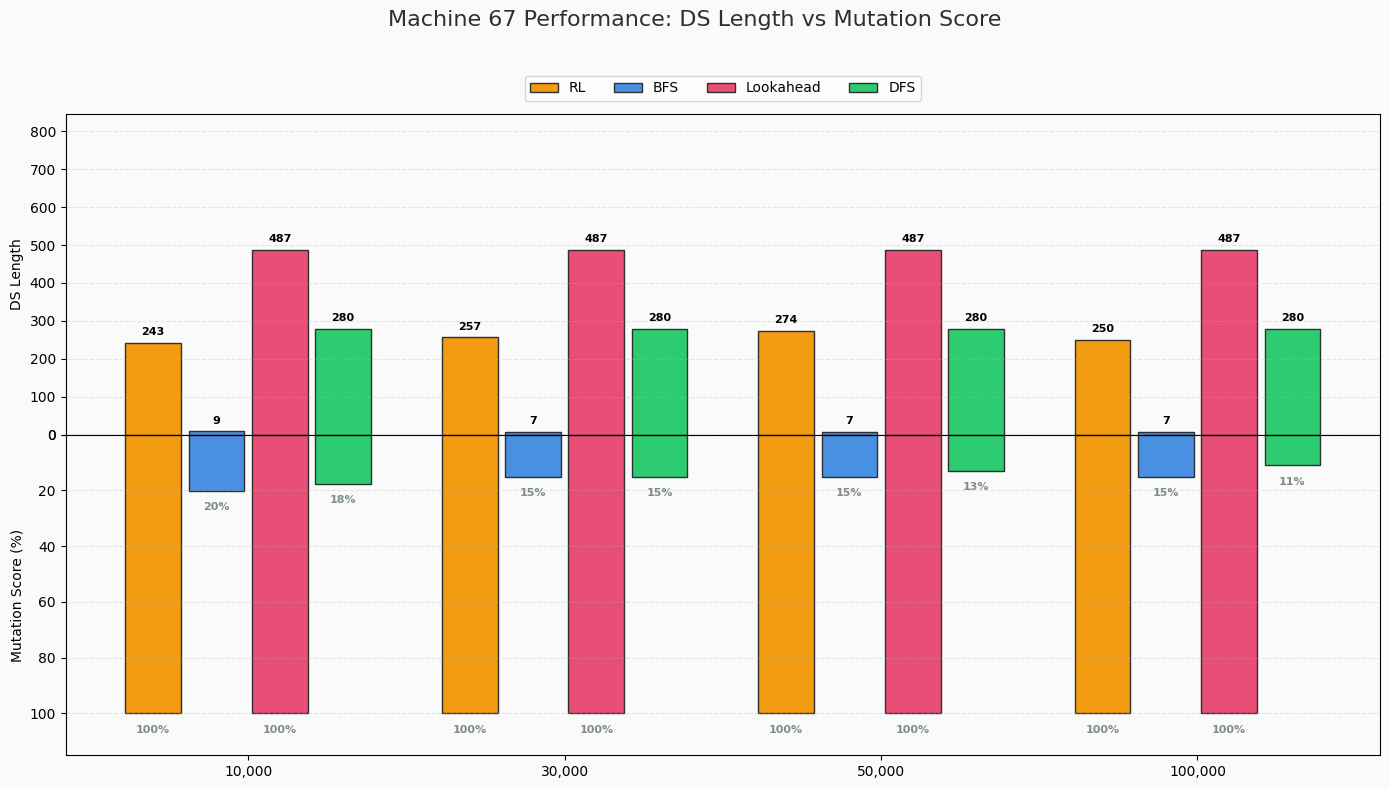

Saved plot for Machine 96 to: /Users/noshin/Desktop/Dr.Khalid/Cery results/Machine_96_Results.png


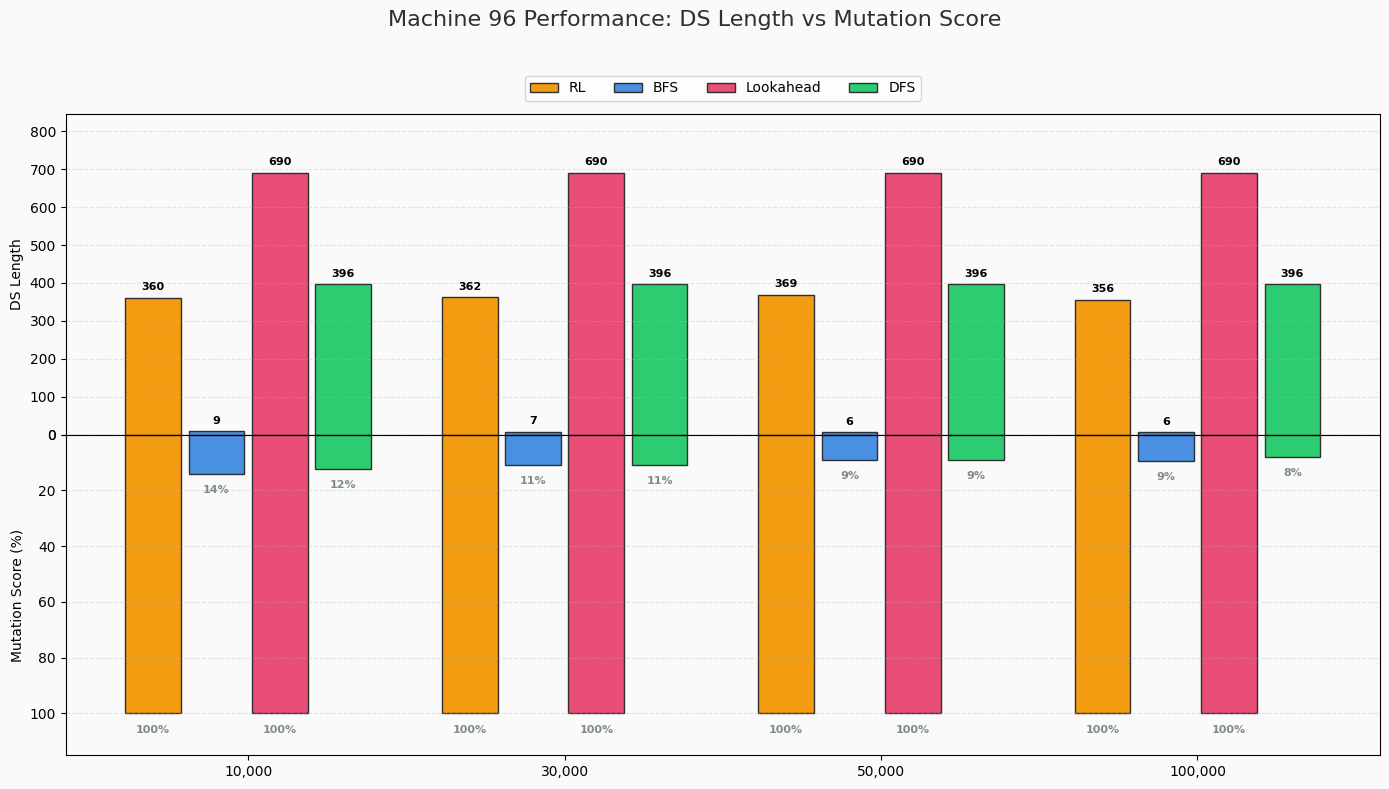

Saved plot for Machine 97 to: /Users/noshin/Desktop/Dr.Khalid/Cery results/Machine_97_Results.png


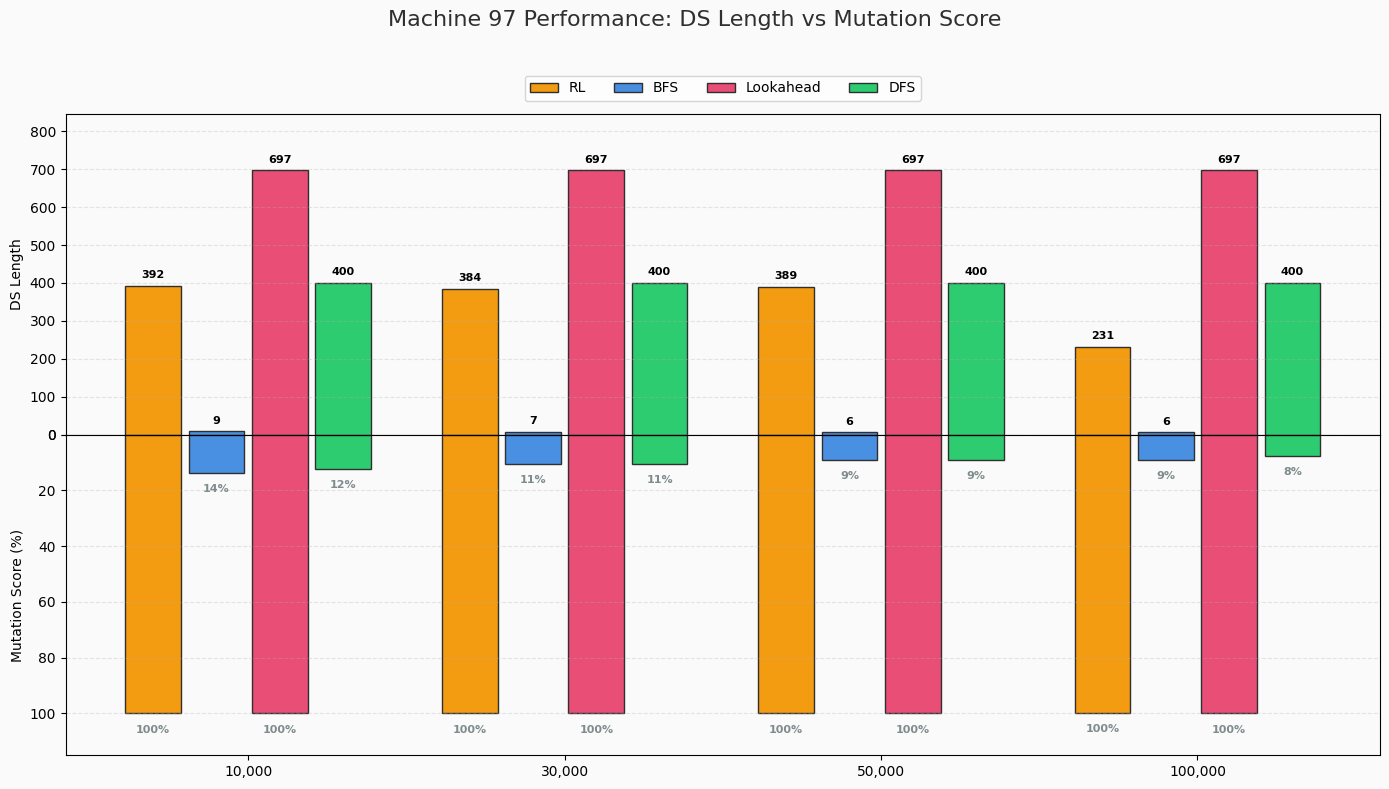

Saved plot for Machine 98 to: /Users/noshin/Desktop/Dr.Khalid/Cery results/Machine_98_Results.png


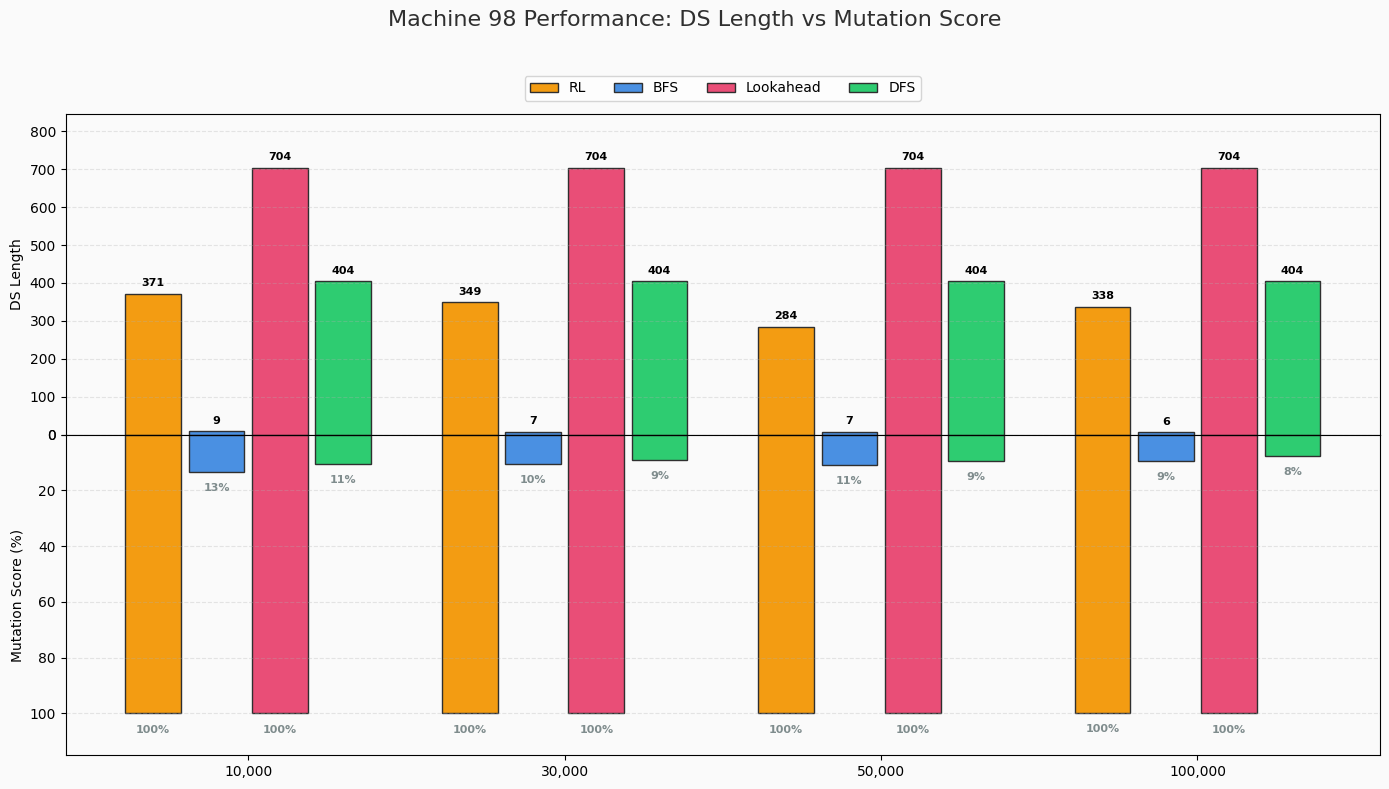

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== CONFIGURATION =====================
# Set this to True to include 100k results, or False to exclude them
INCLUDE_100K = True 

# ===================== PATH =====================
base_dir = Path("/Users/noshin/Desktop/Dr.Khalid/Cery results")

bnb_path = base_dir / "All_BnB_results_cery.xlsx"
rl_path  = base_dir / "All_RL_results_cery.xlsx" # Updated
bfs_path = base_dir / "Combined_BFS_4n.xlsx"
dfs_path = base_dir / "Combined_DFS_4n.xlsx"

# ===================== LOAD DATA =====================
def load_and_prep(path, method_name):
    try:
        df = pd.read_excel(path)
        df.columns = [c.strip() for c in df.columns]
        
        ds_col = "DS Length after 6min"
        ms_col = "Mutation Score after 6min (%)"
        
        # Fallback logic for column names
        if ds_col not in df.columns:
            ds_cols = [c for c in df.columns if "DS Length" in c]
            ds_col = ds_cols[-1] if ds_cols else None
        if ms_col not in df.columns:
            ms_cols = [c for c in df.columns if "Mutation Score" in c]
            ms_col = ms_cols[-1] if ms_cols else None
        
        if not ds_col: return pd.DataFrame()
                
        cols_to_keep = ["Number of Mutants", "Machine #", ds_col]
        if ms_col: cols_to_keep.append(ms_col)
        
        sub = df[cols_to_keep].copy()
        sub["Method"] = method_name
        sub.rename(columns={ds_col: "DS Length"}, inplace=True)
        if ms_col: sub.rename(columns={ms_col: "Mutation Score"}, inplace=True)
        
        return sub
    except Exception as e:
        print(f"Warning: Could not load {method_name}. Error: {e}")
        return pd.DataFrame()

# Combine Data
df_list = [
    load_and_prep(rl_path, "RL"),
    load_and_prep(bfs_path, "BFS"),
    load_and_prep(bnb_path, "Lookahead"),
    load_and_prep(dfs_path, "DFS")
]
full_df = pd.concat(df_list, ignore_index=True)

# ===================== FILTERING =====================
full_df = full_df[full_df["Number of Mutants"] != 200000]
if not INCLUDE_100K:
    full_df = full_df[full_df["Number of Mutants"] != 100000]

# Get list of unique machines (usually 4 machines based on your prompt)
machines = sorted(full_df["Machine #"].unique())

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"
COLORS = {"RL": "#F39C12", "BFS": "#4A90E2", "Lookahead": "#E94E77", "DFS": "#2ECC71"}
METHOD_ORDER = ["RL", "BFS", "Lookahead", "DFS"]
GROUP_WIDTH = 0.8

# ===================== PLOT LOOP (4 TIMES) =====================
for machine_id in machines:
    # Filter data for just this machine
    m_df = full_df[full_df["Machine #"] == machine_id].copy()
    
    # Pivot for plotting
    agg_ds = m_df.pivot(index="Number of Mutants", columns="Method", values="DS Length")
    agg_ms = m_df.pivot(index="Number of Mutants", columns="Method", values="Mutation Score")
    
    # Ensure all methods exist in columns for consistency
    for m in METHOD_ORDER:
        if m not in agg_ds.columns: agg_ds[m] = np.nan
        if m not in agg_ms.columns: agg_ms[m] = np.nan
    
    agg_ds = agg_ds.sort_index()
    agg_ms = agg_ms.sort_index()
    
    mutants = agg_ds.index.values
    x = np.arange(len(mutants))
    bar_width = GROUP_WIDTH / len(METHOD_ORDER)

    fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), 
                                            sharex=True, gridspec_kw={'hspace': 0})
    fig.patch.set_facecolor(BG)
    fig.suptitle(f"Machine {machine_id} Performance: DS Length vs Mutation Score", fontsize=16, color=EDGE)

    for ax in (ax_top, ax_bottom):
        ax.set_facecolor(BG)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')

    # Plot Bars
    for i, method in enumerate(METHOD_ORDER):
        y_ds = agg_ds[method].values
        y_ms = agg_ms[method].values
        positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

        bars_ds = ax_top.bar(positions, y_ds, width=bar_width*0.88, color=COLORS[method], edgecolor=EDGE, label=method)
        bars_ms = ax_bottom.bar(positions, y_ms, width=bar_width*0.88, color=COLORS[method], edgecolor=EDGE)

        # Labels
        for b_up, b_down, val_ds, val_ms in zip(bars_ds, bars_ms, y_ds, y_ms):
            if pd.notna(val_ds):
                ax_top.text(center_x := b_up.get_x() + b_up.get_width()/2, val_ds + 15, f"{val_ds:.0f}", 
                            ha='center', va='bottom', fontsize=8, fontweight='bold')
            if pd.notna(val_ms):
                ax_bottom.text(center_x, val_ms + 4, f"{val_ms:.0f}%", 
                               ha='center', va='top', fontsize=8, fontweight='bold', color="#7F8C8D")

    # Axes Styling
    ax_bottom.set_xticks(x)
    ax_bottom.set_xticklabels([f"{int(m):,}" for m in mutants])
    ax_top.set_ylabel("DS Length")
    ax_bottom.set_ylabel("Mutation Score (%)")
    
    # Global Limits
    ax_top.set_ylim(0, full_df["DS Length"].max() * 1.2)
    ax_bottom.set_ylim(115, 0)
    
    # ax_top.spines['bottom'].set_linewidth(1)
    ax_bottom.spines['top'].set_visible(True)
    ax_top.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=4)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save each machine separately
    save_path = base_dir / f"Machine_{machine_id}_Results.png"
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot for Machine {machine_id} to: {save_path}")
    plt.show()

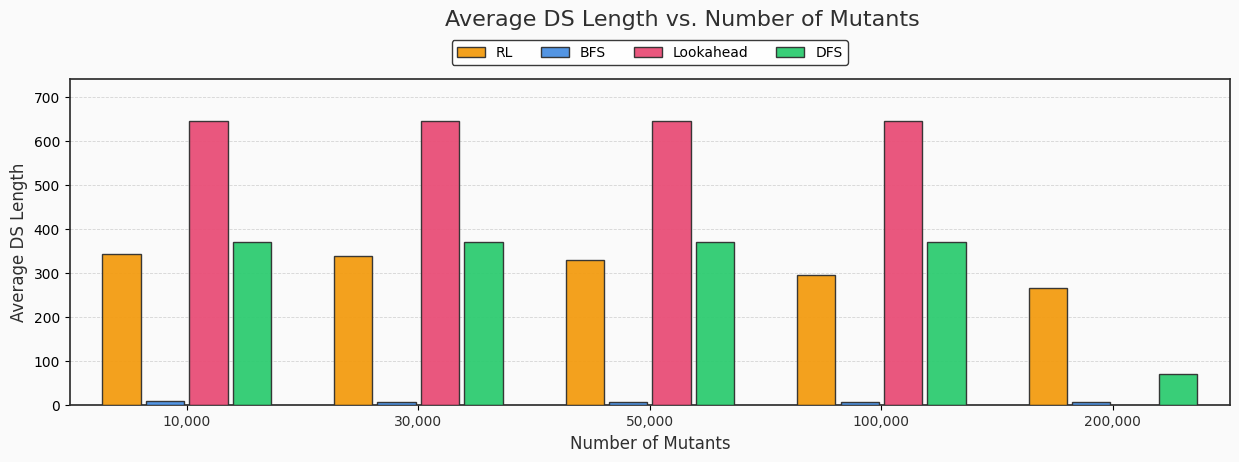

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

base_dir = Path("/Users/noshin/Desktop/Dr.Khalid/Cery results")

# 1. Define the mapping of Methods to their respective files
# (Update these names if your local file names are different)
file_mapping = {
    "Lookahead": "/Users/noshin/Desktop/Dr.Khalid/Cery results/All_BnB_results_cery.xlsx",
    "RL":  "/Users/noshin/Desktop/Dr.Khalid/Cery results/All_RL_results_cery.xlsx",
    "BFS": "/Users/noshin/Desktop/Dr.Khalid/Cery results/Combined_BFS_4n.xlsx",
    "DFS": "/Users/noshin/Desktop/Dr.Khalid/Cery results/Combined_DFS_4n.xlsx"
}

# 2. LOAD DATA DYNAMICALLY
all_dfs = []
for method, filename in file_mapping.items():
    if os.path.exists(filename):
        # Read file (works for both .csv and .xlsx)
        df_temp = pd.read_excel(filename) if filename.endswith('.xlsx') else pd.read_csv(filename)
        
        # Clean column names (strip spaces)
        df_temp.columns = [c.strip() for c in df_temp.columns]
        
        # Define the target columns
        mutant_col = "Number of Mutants"
        ds_col = "DS Length after 6min" # Using the final result column
        
        if mutant_col in df_temp.columns and ds_col in df_temp.columns:
            # Extract just what we need
            subset = df_temp[[mutant_col, ds_col]].copy()
            subset["Method"] = method
            
            # Ensure numeric data for calculations
            subset[mutant_col] = pd.to_numeric(subset[mutant_col], errors='coerce')
            subset[ds_col] = pd.to_numeric(subset[ds_col], errors='coerce')
            
            all_dfs.append(subset)
        else:
            print(f"Warning: Required columns not found in {filename}")

# 3. COMBINE AND PROCESS
if all_dfs:
    full_df = pd.concat(all_dfs, ignore_index=True).dropna()
    
    # Average the DS length across machines for each mutant size and each method
    # This creates the agg_df your plot expects
    agg_df = full_df.groupby(["Number of Mutants", "Method"])["DS Length after 6min"].mean().unstack().reset_index()
    
    # Fill missing methods with NaN if a file was missing
    for m in ["RL", "BFS", "Lookahead", "DFS"]:
        if m not in agg_df.columns:
            agg_df[m] = np.nan
            
    # Sort by Number of Mutants in ascending order
    agg_df = agg_df.sort_values("Number of Mutants", ascending=True)

    # ===================== STYLE (Your Custom Style) =====================
    EDGE = "#2F2F2F"
    BG   = "#FAFAFA"
    GRID = "gray"

    COLORS = {
        "RL": "#F39C12",        # Deep Gold
        "BFS": "#4A90E2",       # Professional Blue
        "Lookahead": "#E94E77", # Soft Crimson
        "DFS": "#2ECC71",       # Bright Green
    }

    GROUP_WIDTH = 0.75
    METHOD_ORDER = ["RL", "BFS", "Lookahead", "DFS"]

    # ===================== PLOT =====================
    mutants = agg_df["Number of Mutants"].values
    x = np.arange(len(mutants))
    n = len(METHOD_ORDER)
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    # Y-axis grid only
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    # === HEADER ===
    fig.suptitle("Average DS Length vs. Number of Mutants",
                 fontsize=16, color=EDGE, y=0.88, x=0.55)

    # === BARS ===
    max_height = 0
    for i, method in enumerate(METHOD_ORDER):
        y = agg_df[method].values
        
        # Track max height for Y-axis scaling
        valid_y = [val for val in y if not np.isnan(val)]
        if valid_y and max(valid_y) > max_height:
            max_height = max(valid_y)

        positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

        ax.bar(
            positions, y,
            width=bar_width * 0.88,
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3
        )

    # === AXES & TICKS ===
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(m):,}" for m in mutants], fontsize=10, color=EDGE)

    ax.set_xlabel("Number of Mutants", fontsize=12, color=EDGE)
    ax.set_ylabel("Average DS Length", fontsize=12, color=EDGE)

    # Dynamic Y-axis
    ax.set_ylim(0, max_height * 1.15 if max_height > 0 else 100)

    # === FRAME ===
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # === LEGEND ===
    leg = ax.legend(
            loc="lower center",
            bbox_to_anchor=(0.5, 1.02),  
            ncol=n,
            frameon=True,
            framealpha=0.95,
            fancybox=True,
            fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    # Show plot
    plt.show()
else:
    print("Error: No data loaded. Check if the file names in 'file_mapping' are correct.")

In [67]:
import pandas as pd
from pathlib import Path

# ===================== PATH =====================
# Update this to exactly where your individual files are stored
base_dir = Path('/Users/noshin/Desktop/Dr.Khalid/All Results/BFS')

# List of the files you want to combine
files_to_combine = [
    "final_bfs_results_128state_fsms_partial_10000.xlsx",
    "final_bfs_results_128state_fsms_partial_30000.xlsx",
    "final_bfs_results_128state_fsms_partial_50000.xlsx",
    "final_bfs_results_128state_fsms_partial_100000.xlsx"
]

# ===================== LOAD & COMBINE =====================
dfs = []

for file_name in files_to_combine:
    file_path = base_dir / file_name
    print(f"Reading {file_name}...")
    try:
        # Read the excel file
        df = pd.read_excel(file_path)
        dfs.append(df)
    except Exception as e:
        print(f"Failed to read {file_name}. Error: {e}")

if dfs:
    # Concatenate all dataframes vertically
    combined_df = pd.concat(dfs, ignore_index=True)
    
    # ===================== EXPORT =====================
    output_path = base_dir / "Combined_BFS_partial.xlsx"
    
    # Save to a new Excel file without the index column
    combined_df.to_excel(output_path, index=False)
    
    print(f"\nSuccess! Combined {len(dfs)} files.")
    print(f"Total rows in combined file: {len(combined_df)}")
    print(f"Saved to: {output_path}")
else:
    print("No data was loaded. Please check the file paths.")

Reading final_bfs_results_128state_fsms_partial_10000.xlsx...
Reading final_bfs_results_128state_fsms_partial_30000.xlsx...
Reading final_bfs_results_128state_fsms_partial_50000.xlsx...
Reading final_bfs_results_128state_fsms_partial_100000.xlsx...

Success! Combined 4 files.
Total rows in combined file: 400
Saved to: /Users/noshin/Desktop/Dr.Khalid/All Results/BFS/Combined_BFS_partial.xlsx


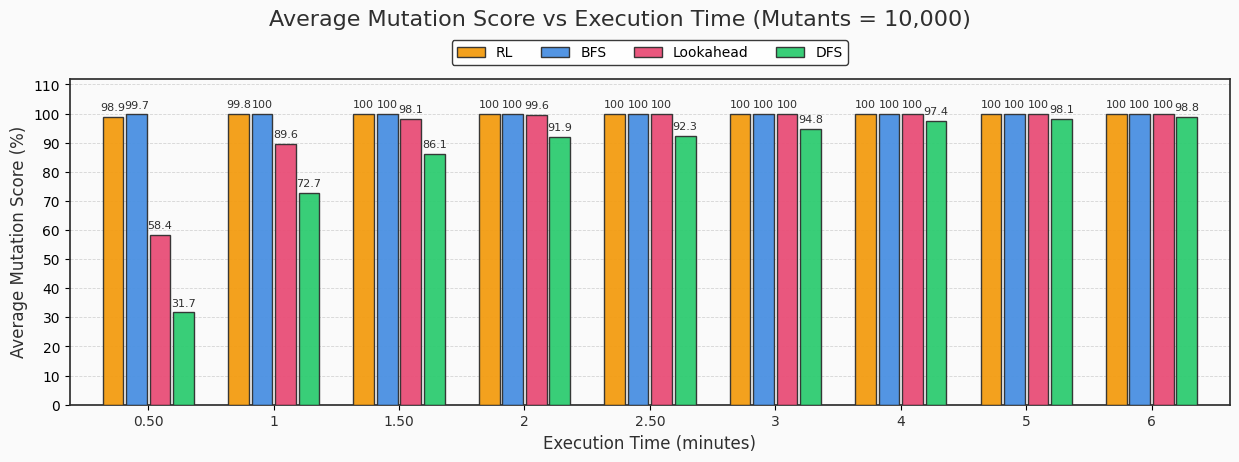

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_10000.png


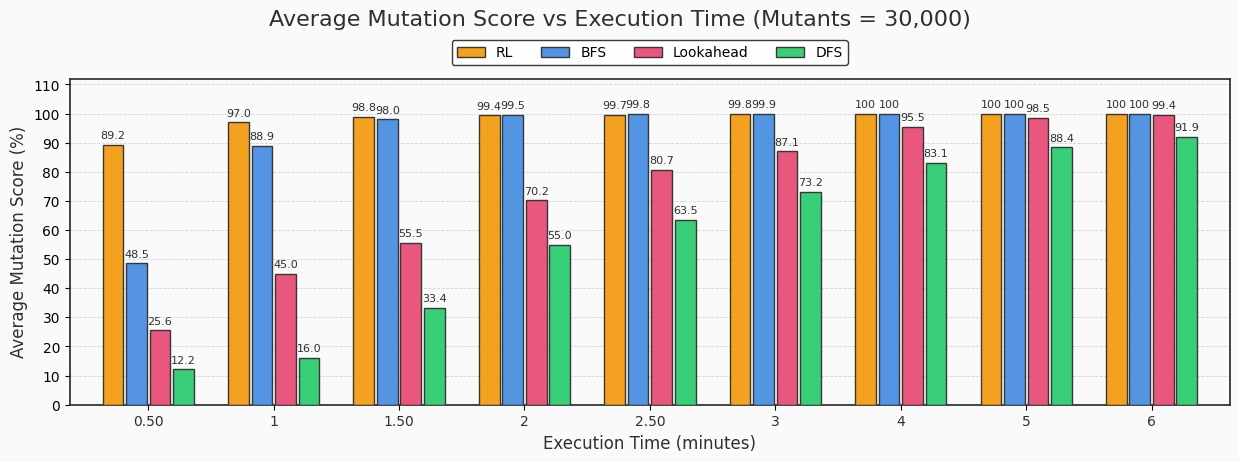

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_30000.png


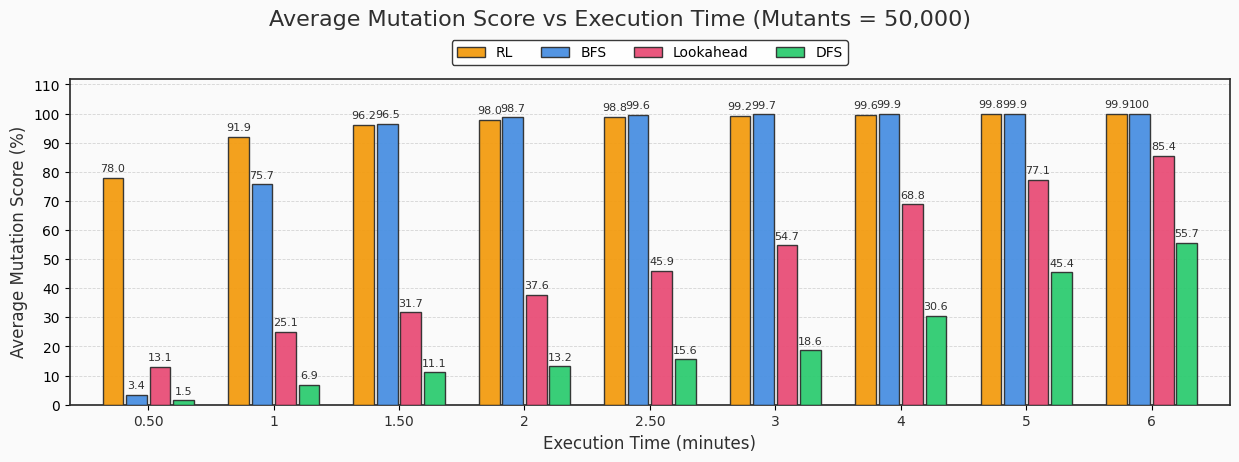

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_50000.png


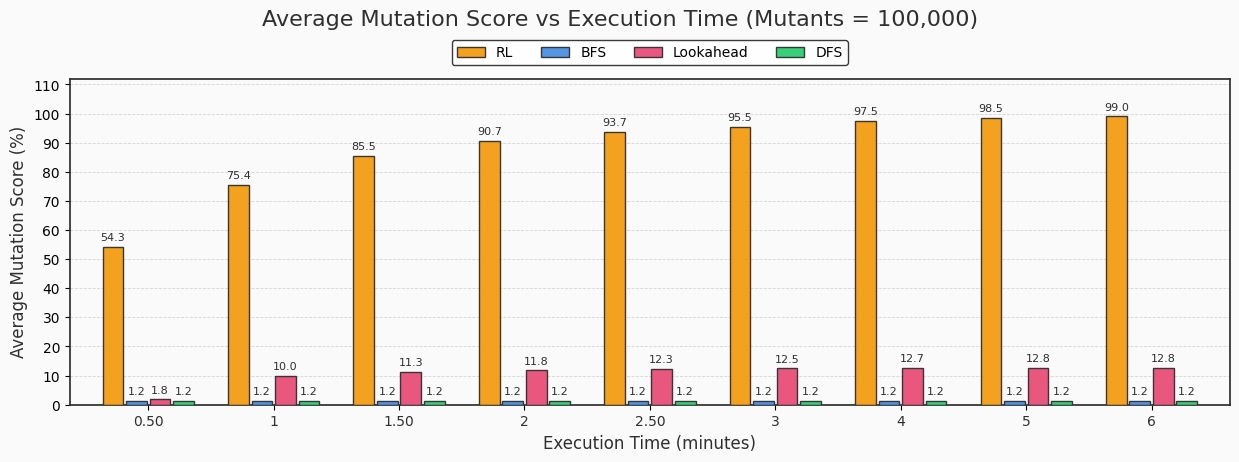

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_100000.png


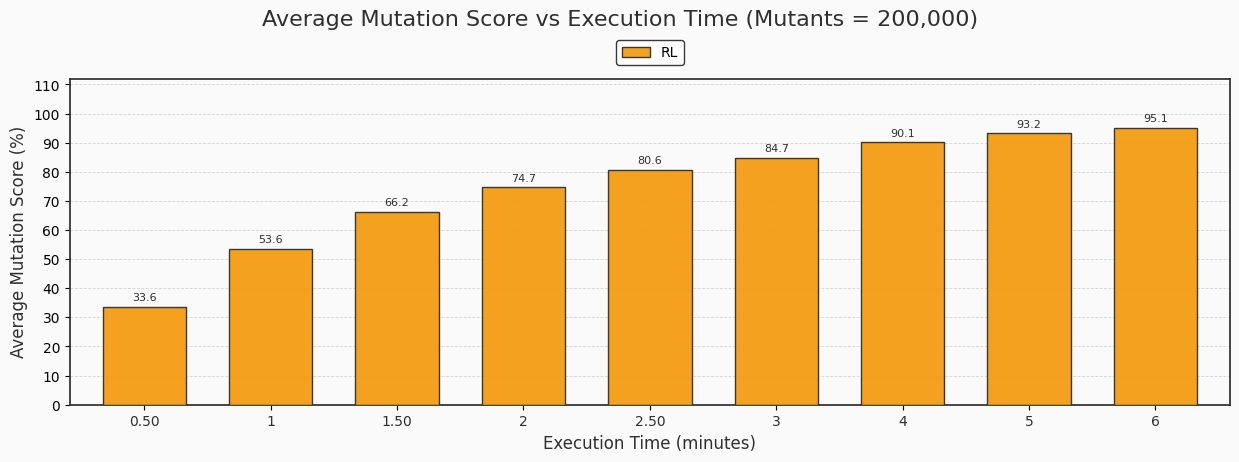

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_200000.png


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ===================== PATH =====================
base_dir = Path('/Users/noshin/Desktop/Dr.Khalid/All Results')

bnb_path = base_dir / "BnB/Combined_BNB_4n.xlsx"
rl_path  = base_dir / "RL/100 Real Machines/All_RL_results_our_generator.xlsx"
bfs_path = base_dir / 'BFS/Combined_BFS_complete.xlsx'
dfs_path = base_dir / 'DFS/Combined_DFS_complete.xlsx'

# ===================== LOAD =====================
bnb_df = pd.read_excel(bnb_path); bnb_df["Method"] = "Lookahead"
rl_df  = pd.read_excel(rl_path);  rl_df["Method"]  = "RL"
bfs_df = pd.read_excel(bfs_path); bfs_df["Method"] = "BFS"
dfs_df = pd.read_excel(dfs_path); dfs_df["Method"] = "DFS"

df = pd.concat([bnb_df, rl_df, bfs_df, dfs_df], ignore_index=True)

# Normalize "Number of Mutants" column name if needed
if "Number of Mutants" not in df.columns:
    for c in df.columns:
        if "Mutant" in c and "Number" in c:
            df.rename(columns={c: "Number of Mutants"}, inplace=True)
            break

# ===================== TIME COLUMN PARSING =====================
score_cols = [c for c in df.columns if re.match(r"^Mutation Score after .* \(%\)$", c)]

def parse_time_to_min(label: str) -> float:
    m = re.search(r"after (.+) \(%\)$", label)
    if not m:
        return None
    t = m.group(1)
    mins = 0.0
    m_min = re.search(r"(\d+)\s*min", t)
    m_sec = re.search(r"(\d+)\s*s", t)
    if m_min:
        mins += float(m_min.group(1))
    if m_sec:
        mins += float(m_sec.group(1)) / 60.0
    if not m_min and not m_sec:
        try:
            mins = float(t)
        except:
            return None
    return mins

time_map = {col: parse_time_to_min(col) for col in score_cols if parse_time_to_min(col) is not None}

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"

# NEW: Updated vibrant, distinct color palette
COLORS = {
    "RL": "#F39C12", # Deep Gold
    "BFS": "#4A90E2", # Professional Blue
    "Lookahead": "#E94E77", # Soft Crimson
    "DFS": "#2ECC71", # Bright Green
}

GROUP_WIDTH = 0.75
ANNOTATE_EVERY = 1

ORDERED_MUTANTS = [10000, 30000, 50000, 100000, 200000]
present_mutants = [m for m in ORDERED_MUTANTS if (df["Number of Mutants"] == m).any()]
if not present_mutants:
    present_mutants = sorted(df["Number of Mutants"].dropna().unique().tolist())

# ===================== PLOT FUNCTION =====================
def make_bar_plot_for_mutants(mutants_value: int):
    sub = df[df["Number of Mutants"] == mutants_value].copy()
    if sub.empty:
        return

    # Aggregate mean mutation score per (method, time)
    rows = []
    for method in sub["Method"].unique():
        subm = sub[sub["Method"] == method]
        for col, tmin in time_map.items():
            if col in subm.columns:
                rows.append([tmin, method, subm[col].mean(skipna=True)])
    plot_df = pd.DataFrame(rows, columns=["Time (min)", "Method", "Avg Mutation Score (%)"])

    # Pivot to (times x methods)
    pivot_df = plot_df.pivot_table(index="Time (min)", columns="Method",
                                values="Avg Mutation Score (%)").sort_index()

    # Force the bar order: RL first
    METHOD_ORDER = ["RL", "BFS", "Lookahead", "DFS"]
    # Keep only methods that actually exist in the data
    methods = [m for m in METHOD_ORDER if m in pivot_df.columns]
    pivot_df = pivot_df[methods]

    times = pivot_df.index.values
    x = np.arange(len(times))
    n = len(methods)
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    
    # === CHANGED LINE: Added axis='y' to only show horizontal grid lines ===
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    # === HEADER ===
    fig.suptitle(f"Average Mutation Score vs Execution Time (Mutants = {mutants_value:,})",
                 fontsize=16, color=EDGE, y = 0.88, x = 0.5)

    # === BARS ===
    for i, method in enumerate(methods):
        y = pivot_df[method].values
        positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

        bars = ax.bar(
            positions, y,
            width=bar_width * 0.88,
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3
        )

        # value labels
        for j, b in enumerate(bars):
            if (j % ANNOTATE_EVERY) != 0:
                continue
            h = b.get_height()
            
            text_val = "100" if h >= 99.9 else f"{h:.1f}"
            
            ax.text(b.get_x() + b.get_width()/2, h + 1.5, text_val,
                    ha="center", va="bottom", fontsize=8, color=EDGE)

    # ticks centered under each group
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(t)}" if float(t).is_integer() else f"{t:.2f}" for t in times],
                       fontsize=10, color=EDGE)

    # axes labels & limits
    ax.set_xlabel("Execution Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Mutation Score (%)", fontsize=12, color=EDGE)
    ax.set_yticks(np.arange(0, 111, 10))
    ax.set_ylim(0, 112)

    # frame
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # legend
    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),  
        ncol=n,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = base_dir / f"avg_mutation_vs_time_bar_{mutants_value}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

# ===================== RUN =====================
for m in present_mutants:
    make_bar_plot_for_mutants(m)

In [ ]:
import pandas as pd
import os
from pathlib import Path

# 1. Set your path
current_directory = '/Users/noshin/Desktop/Dr.Khalid/All Results/DFS'

# 2. Find any files containing 'our_generator' (CSV or Excel)
# Changed filter from 'cery_machines' to 'our_generator'
files = [
    f for f in os.listdir(current_directory) 
    if 'our_generator' in f.lower() and (f.endswith('.xlsx') or f.endswith('.csv'))
]

print(f"Files found: {files}")

df_list = []
for file in files:
    file_path = os.path.join(current_directory, file)
    try:
        # Detect file type and read
        if file.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)
        
        # Clean column names in case of leading/trailing spaces
        df.columns = [c.strip() for c in df.columns]
        
        df_list.append(df)
        print(f"Successfully loaded: {file}")
    except Exception as e:
        print(f"Could not read {file}: {e}")

# 3. Combine and Sort
if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # Ensure 'Number of Mutants' is treated as a number for correct sorting
    column_name = 'Number of Mutants'
    if column_name in combined_df.columns:
        combined_df[column_name] = pd.to_numeric(combined_df[column_name], errors='coerce')
        combined_df = combined_df.dropna(subset=[column_name])
        combined_df_sorted = combined_df.sort_values(by=column_name, ascending=True)
        print(f"Sorted by {column_name} (Ascending)")
    else:
        print(f"Warning: Column '{column_name}' not found. Saving unsorted.")
        combined_df_sorted = combined_df

    # 4. Save to Excel
    output_path = os.path.join(current_directory, 'combined_our_generator_results.xlsx')
    combined_df_sorted.to_excel(output_path, index=False)
    
    print(f"\nSuccess! Combined {len(df_list)} files.")
    print(f"Final file saved at: {output_path}")
else:
    print("\nNo matching files found with 'our_generator' in the name.")

Files found: ['DFS_results_128state_fsms_complete_100000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_30000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_10000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_50000_our_generator.xlsx']
Successfully loaded: DFS_results_128state_fsms_complete_100000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_30000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_10000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_50000_our_generator.xlsx
Sorted by Number of Mutants (Ascending)

Success! Combined 4 files.
Final file saved at: /Users/noshin/Desktop/Dr.Khalid/All Results/DFS/combined_our_generator_results.xlsx


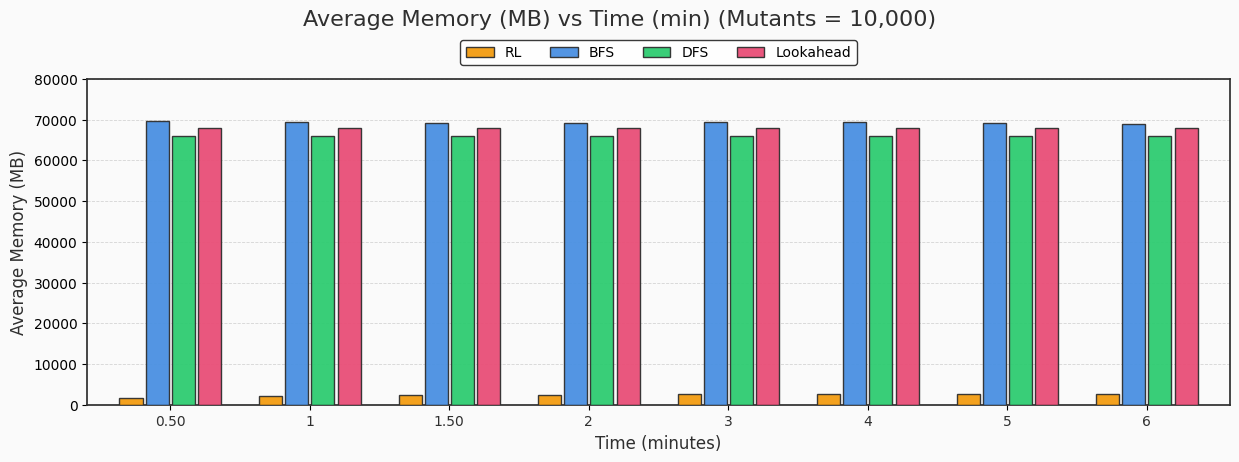

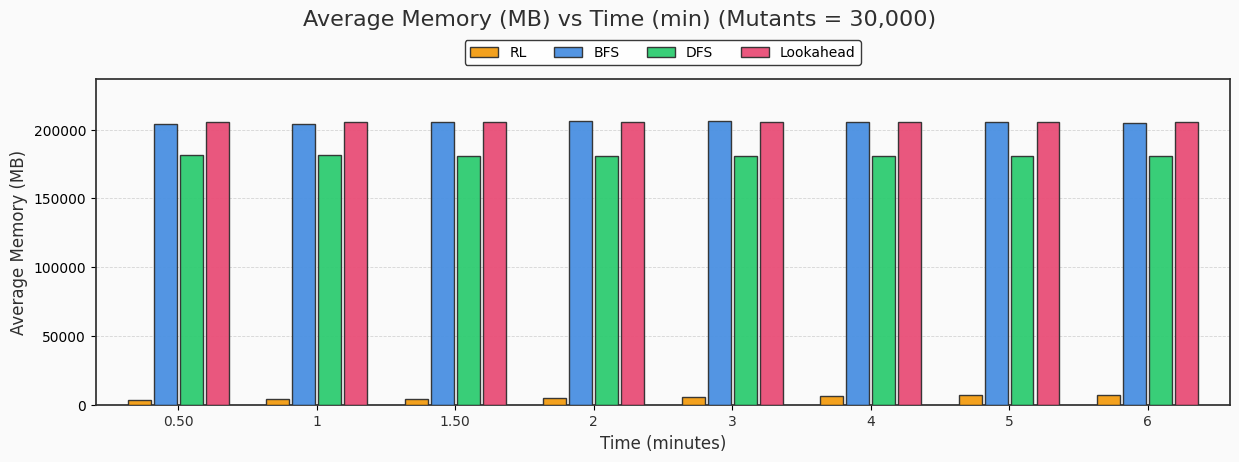

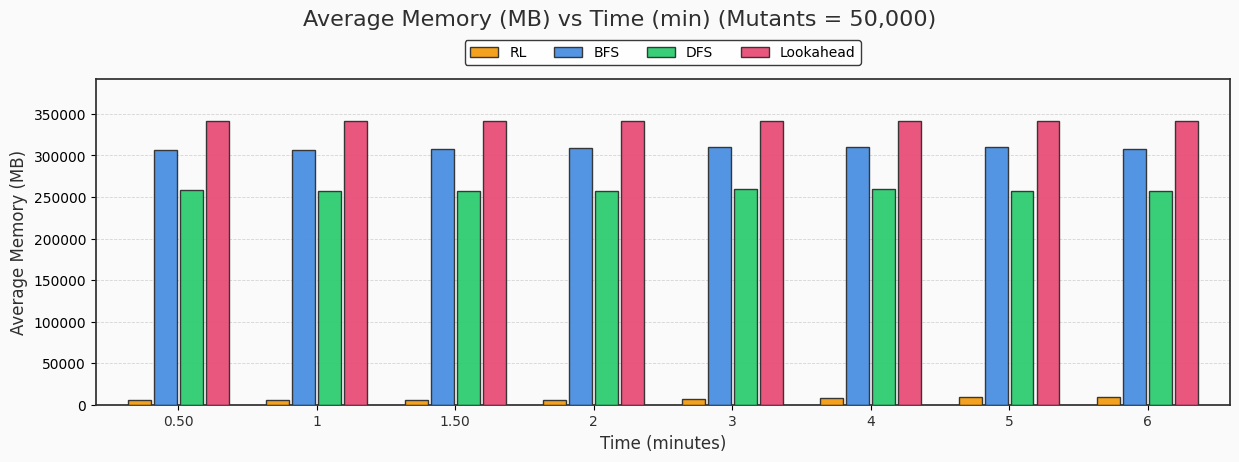

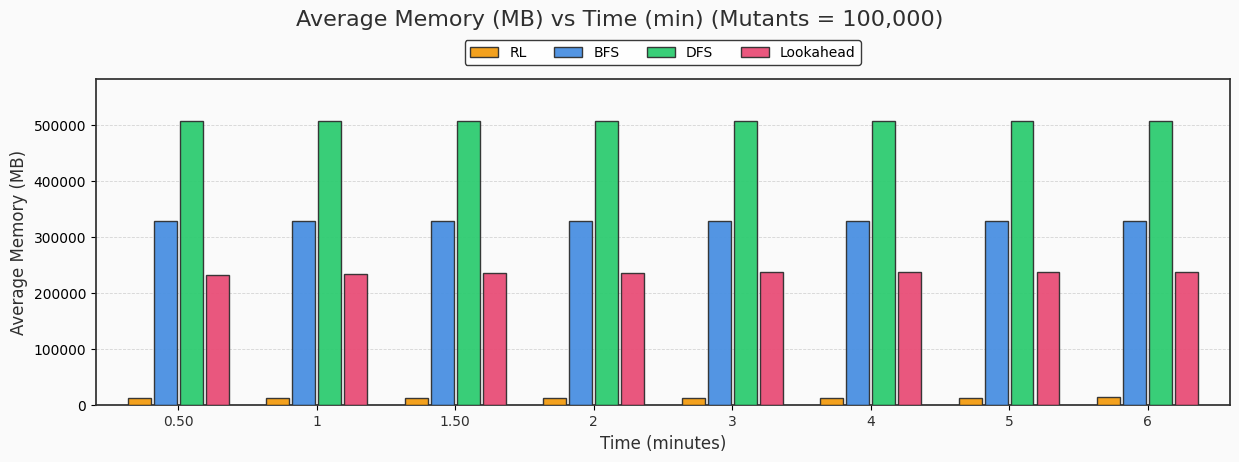

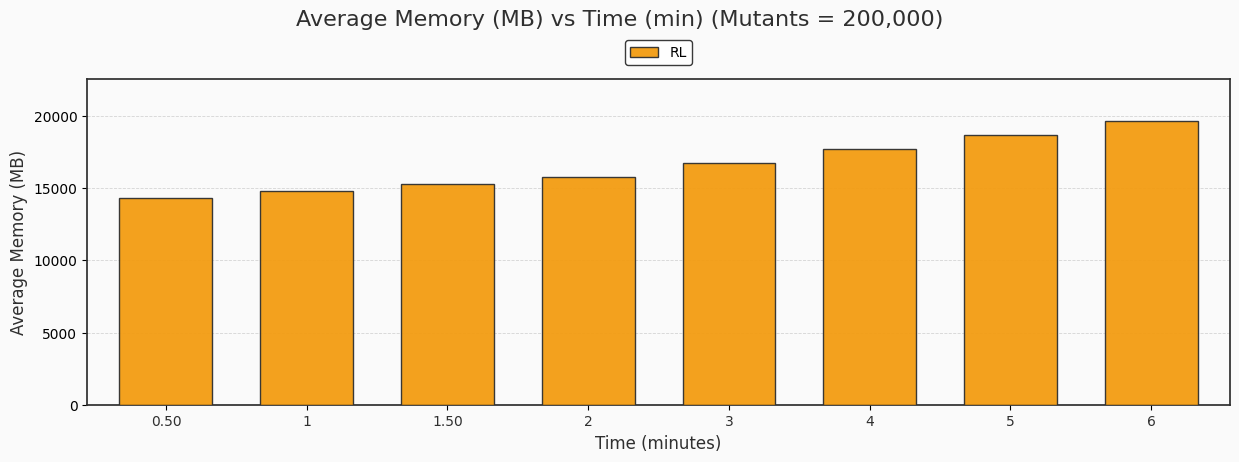

Saved figures:
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_10000.png
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_30000.png
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_50000.png
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_100000.png
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_200000.png
Saved data table: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_agg.csv


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from typing import Optional, Union

# ===================== PATH =====================
base_dir = Path('/Users/noshin/Desktop/Dr.Khalid/All Results')

bnb_path = base_dir / "BnB/Combined_BNB_4n.xlsx"
rl_path  = base_dir / "RL/100 Real Machines/All_RL_results_our_generator.xlsx"
bfs_path = base_dir / 'BFS/Combined_BFS_complete.xlsx'
dfs_path = base_dir / 'DFS/Combined_DFS_complete.xlsx'

# ===================== LOAD =====================
def load_with_method(path: Path, method: str) -> pd.DataFrame:
    try:
        xl = pd.ExcelFile(path)
        frames = []
        for sh in xl.sheet_names:
            df = xl.parse(sh)
            df["__sheet__"] = sh
            frames.append(df)
        out = pd.concat(frames, ignore_index=True)
        out["Method"] = method
        return out
    except Exception as e:
        print(f"Warning: Could not load {path}. Error: {e}")
        return pd.DataFrame()

# "BnB" is now "Lookahead"
bnb = load_with_method(bnb_path, "Lookahead")
rl  = load_with_method(rl_path, "RL")
bfs = load_with_method(bfs_path, "BFS")
dfs = load_with_method(dfs_path, "DFS")

df = pd.concat([bnb, rl, bfs, dfs], ignore_index=True)

if df.empty:
    print("Error: No data loaded. Check paths.")
    exit()

# ===================== NORMALIZE "Number of Mutants" =====================
mut_col = None
for c in df.columns:
    cl = str(c).strip().lower()
    if ("mutant" in cl) and ("number" in cl or "count" in cl or cl in {"mutants","num_mutants","n_mutants","no. of mutants"}):
        mut_col = c
        break
if mut_col is None and "Number of Mutants" in df.columns:
    mut_col = "Number of Mutants"
if mut_col is None:
    df["Number of Mutants"] = np.nan
else:
    df.rename(columns={mut_col: "Number of Mutants"}, inplace=True)

# ===================== DETECT MEMORY-AT-TIME COLUMNS =====================
def extract_minutes(colname: str) -> Optional[float]:
    s = colname.lower()
    if ("memory" not in s) or ("after" not in s):
        return None
    m_min = re.search(r"(\d+(?:\.\d+)?)\s*min", s)
    m_sec = re.search(r"(\d+(?:\.\d+)?)\s*s(?![a-z])", s)
    found = False
    minutes = 0.0
    if m_min:
        minutes += float(m_min.group(1)); found = True
    if m_sec:
        minutes += float(m_sec.group(1)) / 60.0; found = True
    if not found:
        try:
            minutes = float(re.search(r"(\d+(?:\.\d+)?)", s).group(1))
            found = True
        except Exception:
            return None
    return minutes

mem_time_cols = {}
for c in df.columns:
    t = extract_minutes(str(c))
    if t is not None:
        mem_time_cols[str(c)] = t

# ===================== FIXED TIME GRID & SNAP =====================
FIXED_TIMES = [0.5, 1, 1.5, 2, 3, 4, 5, 6]  # minutes

def snap_to_grid(x: float, grid=FIXED_TIMES, tol=0.251):  # 15s tolerance
    arr = np.asarray(grid, dtype=float)
    i = np.argmin(np.abs(arr - x))
    if abs(arr[i] - x) <= tol:
        return float(arr[i])
    return np.nan

# ===================== LONG-FORM DATA =====================
rows = []
for _, r in df.iterrows():
    for col, t in mem_time_cols.items():
        mem_val = pd.to_numeric(r.get(col, np.nan), errors="coerce")
        if pd.notna(mem_val):
            tfix = snap_to_grid(t)
            if not np.isnan(tfix):
                rows.append([
                    r.get("Method", None),
                    r.get("Number of Mutants", None),
                    tfix,
                    float(mem_val)
                ])

long = pd.DataFrame(rows, columns=["Method", "Number of Mutants", "Time (min)", "Memory (MB)"])
agg = (long.groupby(["Number of Mutants", "Method", "Time (min)"])["Memory (MB)"]
           .mean()
           .reset_index()
           .sort_values(["Number of Mutants", "Method", "Time (min)"]))

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"

COLORS = {
    "BFS": "#4A90E2", 
    "Lookahead": "#E94E77", 
    "DFS": "#2ECC71", 
    "RL":  "#F39C12"  
}

GROUP_WIDTH = 0.75         

# ===================== PLOT (ONE FIGURE PER #MUTANTS) =====================
ORDERED_MUTANTS = [10000, 30000, 50000, 100000, 200000]
present_mutants = [m for m in ORDERED_MUTANTS if (agg["Number of Mutants"] == m).any()]
if not present_mutants:
    present_mutants = sorted(pd.unique(agg["Number of Mutants"].dropna()))

def plot_one_bar(mutants_value: Union[int, float]) -> Optional[Path]:
    sub = agg[agg["Number of Mutants"] == mutants_value]
    if sub.empty: return None

    # Pivot the data to get Times as rows and Methods as columns
    pivot_df = sub.pivot_table(index="Time (min)", columns="Method", values="Memory (MB)").reindex(FIXED_TIMES)

    times = pivot_df.index.values
    x = np.arange(len(times))
    
    # CHANGED: "RL" is now explicitly first in the rendering order
    ordered_methods = ["RL", "BFS", "DFS", "Lookahead"]
    methods = [m for m in ordered_methods if m in pivot_df.columns]
    
    if not methods: 
        methods = list(pivot_df.columns)
        
    n = len(methods)
    if n == 0: return None
    
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    # === HEADER ===
    fig.suptitle(f"Average Memory (MB) vs Time (min) (Mutants = {int(mutants_value):,})",
                 fontsize=16, color=EDGE, y=0.88, x=0.5)

    # === BARS ===
    max_height = 0
    for i, method in enumerate(methods):
        y = pivot_df[method].values
        
        # Track maximum height for setting y-axis limits dynamically
        valid_y = [val for val in y if not np.isnan(val)]
        if valid_y and max(valid_y) > max_height:
            max_height = max(valid_y)

        positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

        ax.bar(
            positions, y,
            width=bar_width * 0.88, # Gap between bars in group
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3
        )

    # === AXES & TICKS ===
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(t)}" if float(t).is_integer() else f"{t:.2f}" for t in times],
                       fontsize=10, color=EDGE)

    ax.set_xlabel("Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Memory (MB)", fontsize=12, color=EDGE)
    
    # Dynamic Y-axis
    ax.set_ylim(0, max_height * 1.15 if max_height > 0 else 100)

    # === FRAME ===
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # === LEGEND ===
    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),  
        ncol=n,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = base_dir / f"avg_memory_vs_time_bar_{int(mutants_value)}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    
    # Shows the plot directly in your Jupyter Notebook
    plt.show() 
    
    return out

# ===================== RUN =====================
saved_paths = []
for m in present_mutants:
    p = plot_one_bar(m)
    if p is not None:
        saved_paths.append(str(p))

print("Saved figures:")
for p in saved_paths:
    print("-", p)

# Export the aggregated table
agg_csv = base_dir / "avg_memory_vs_time_agg.csv"
agg.to_csv(agg_csv, index=False)
print("Saved data table:", agg_csv)

In [ ]:
import pandas as pd
import os
from pathlib import Path

# 1. Set your path
current_directory = '/Users/noshin/Desktop/Dr.Khalid/All Results/DFS'

# 2. Find any files containing 'our_generator' (CSV or Excel)
# Changed filter from 'cery_machines' to 'our_generator'
files = [
    f for f in os.listdir(current_directory) 
    if 'our_generator' in f.lower() and (f.endswith('.xlsx') or f.endswith('.csv'))
]

print(f"Files found: {files}")

df_list = []
for file in files:
    file_path = os.path.join(current_directory, file)
    try:
        # Detect file type and read
        if file.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)
        
        # Clean column names in case of leading/trailing spaces
        df.columns = [c.strip() for c in df.columns]
        
        df_list.append(df)
        print(f"Successfully loaded: {file}")
    except Exception as e:
        print(f"Could not read {file}: {e}")

# 3. Combine and Sort
if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # Ensure 'Number of Mutants' is treated as a number for correct sorting
    column_name = 'Number of Mutants'
    if column_name in combined_df.columns:
        combined_df[column_name] = pd.to_numeric(combined_df[column_name], errors='coerce')
        combined_df = combined_df.dropna(subset=[column_name])
        combined_df_sorted = combined_df.sort_values(by=column_name, ascending=True)
        print(f"Sorted by {column_name} (Ascending)")
    else:
        print(f"Warning: Column '{column_name}' not found. Saving unsorted.")
        combined_df_sorted = combined_df

    # 4. Save to Excel
    output_path = os.path.join(current_directory, 'combined_our_generator_results.xlsx')
    combined_df_sorted.to_excel(output_path, index=False)
    
    print(f"\nSuccess! Combined {len(df_list)} files.")
    print(f"Final file saved at: {output_path}")
else:
    print("\nNo matching files found with 'our_generator' in the name.")

Files found: ['DFS_results_128state_fsms_complete_100000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_30000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_10000_our_generator.xlsx', 'DFS_results_128state_fsms_complete_50000_our_generator.xlsx']
Successfully loaded: DFS_results_128state_fsms_complete_100000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_30000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_10000_our_generator.xlsx
Successfully loaded: DFS_results_128state_fsms_complete_50000_our_generator.xlsx
Sorted by Number of Mutants (Ascending)

Success! Combined 4 files.
Final file saved at: /Users/noshin/Desktop/Dr.Khalid/All Results/DFS/combined_our_generator_results.xlsx


Excluding 100k results...


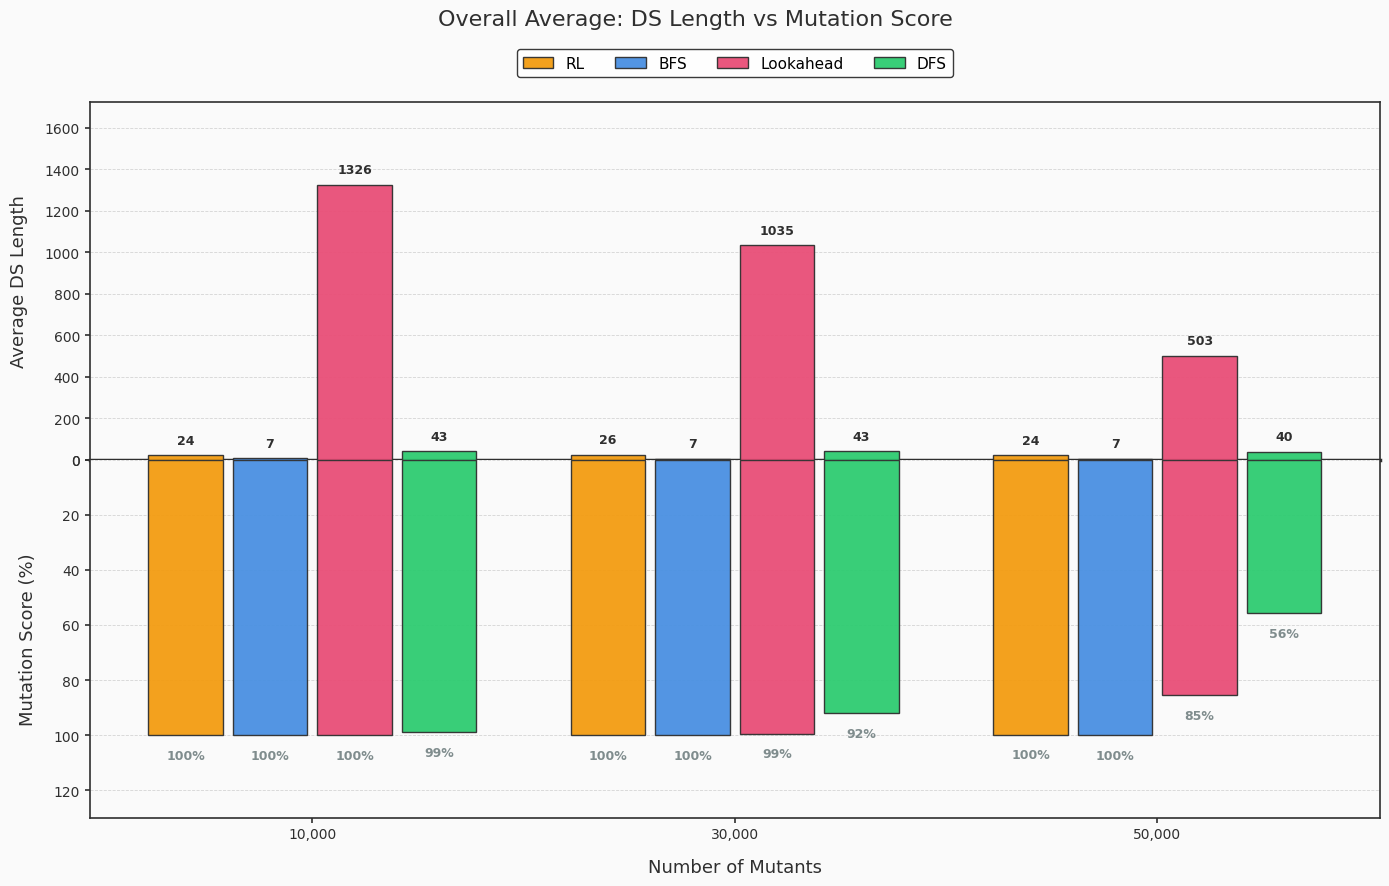

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== CONFIGURATION =====================
# Set this to True to include 100k results, or False to exclude them
INCLUDE_100K = False  # <--- Change this to True/False as needed

# ===================== PATH =====================
base_dir = Path('/Users/noshin/Desktop/Dr.Khalid/All Results')

bnb_path = base_dir / "BnB/Combined_BNB_4n.xlsx"
rl_path  = base_dir / "RL/100 Real Machines/All_RL_results_our_generator.xlsx"
bfs_path = base_dir / 'BFS/Combined_BFS_complete.xlsx'
dfs_path = base_dir / 'DFS/Combined_DFS_complete.xlsx'

# ===================== LOAD DATA =====================
def load_and_prep(path, method_name):
    try:
        df = pd.read_excel(path)
        
        # Check for columns (we take the final DS Length & Mutation Score at 6 minutes)
        ds_col = "DS Length after 6min"
        ms_col = "Mutation Score after 6min (%)"
        
        # Fallback just in case the 6min column name is slightly different
        if ds_col not in df.columns:
            ds_cols = [c for c in df.columns if "DS Length" in c]
            if ds_cols:
                ds_col = ds_cols[-1]
            else:
                return pd.DataFrame()
                
        if ms_col not in df.columns:
            ms_cols = [c for c in df.columns if "Mutation Score" in c]
            if ms_cols:
                ms_col = ms_cols[-1]
            else:
                ms_col = None
                
        cols_to_keep = ["Number of Mutants", ds_col]
        if ms_col: cols_to_keep.append(ms_col)
        
        sub = df[cols_to_keep].copy()
        sub["Method"] = method_name
        
        sub.rename(columns={ds_col: "DS Length"}, inplace=True)
        if ms_col: sub.rename(columns={ms_col: "Mutation Score"}, inplace=True)
        
        return sub
        
    except Exception:
        return pd.DataFrame()

bfs_df = load_and_prep(bfs_path, "BFS")
bnb_df = load_and_prep(bnb_path, "Lookahead")
dfs_df = load_and_prep(dfs_path, "DFS")
rl_df  = load_and_prep(rl_path, "RL")

# Combine all valid dataframes
df = pd.concat([rl_df, bfs_df, bnb_df, dfs_df], ignore_index=True)

if df.empty:
    print("Error: No data loaded. Check paths.")
    exit()

# ===================== FILTERING LOGIC =====================
# 1. Always exclude 200k as per original script
df = df[df["Number of Mutants"] != 200000]

# 2. Toggle 100k inclusion based on the variable at the top
if not INCLUDE_100K:
    df = df[df["Number of Mutants"] != 100000]
    print("Excluding 100k results...")
else:
    print("Including 100k results...")

# ===================== AGGREGATE TO AVERAGE =====================
agg_ds = df.groupby(["Number of Mutants", "Method"])["DS Length"].mean().unstack().reset_index()
agg_ms = df.groupby(["Number of Mutants", "Method"])["Mutation Score"].mean().unstack().reset_index()

METHOD_ORDER = ["RL", "BFS", "Lookahead", "DFS"]
for m in METHOD_ORDER:
    if m not in agg_ds.columns: agg_ds[m] = np.nan
    if m not in agg_ms.columns: agg_ms[m] = np.nan

agg_ds = agg_ds.sort_values(by="Number of Mutants")
agg_ms = agg_ms.sort_values(by="Number of Mutants")

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"
COLORS = {"RL": "#F39C12", "BFS": "#4A90E2", "Lookahead": "#E94E77", "DFS": "#2ECC71"}
GROUP_WIDTH = 0.8

# ===================== PLOT =====================
mutants = agg_ds["Number of Mutants"].values
x = np.arange(len(mutants))
bar_width = GROUP_WIDTH / len(METHOD_ORDER)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(14, 9), 
                                        sharex=True, gridspec_kw={'hspace': 0})
fig.patch.set_facecolor(BG)
fig.suptitle("Overall Average: DS Length vs Mutation Score", fontsize=16, color=EDGE, y=0.98)

for ax in (ax_top, ax_bottom):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y', zorder=0)
    ax.set_axisbelow(True)

max_ds = agg_ds[METHOD_ORDER].max().max()
max_ms = agg_ms[METHOD_ORDER].max().max()

for i, method in enumerate(METHOD_ORDER):
    y_ds = agg_ds[method].values
    y_ms = agg_ms[method].values
    positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

    bars_ds = ax_top.bar(positions, y_ds, width=bar_width * 0.88, label=method,
                         color=COLORS.get(method, "#CCCCCC"), edgecolor=EDGE,
                         linewidth=1, alpha=0.95, zorder=3)
    
    bars_ms = ax_bottom.bar(positions, y_ms, width=bar_width * 0.88, 
                            color=COLORS.get(method, "#CCCCCC"), edgecolor=EDGE,
                            linewidth=1, alpha=0.95, zorder=3)

    # Adding text labels
    pad_ds = max_ds * 0.03 if pd.notna(max_ds) and max_ds > 0 else 5
    pad_ms = max_ms * 0.05 if pd.notna(max_ms) and max_ms > 0 else 5

    for bar_up, bar_down, ds, ms in zip(bars_ds, bars_ms, y_ds, y_ms):
        if pd.notna(ds):
            ax_top.text(bar_up.get_x() + bar_up.get_width() / 2, ds + pad_ds, 
                        f"{ds:.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold', color=EDGE, zorder=4)
        if pd.notna(ms):
            ax_bottom.text(bar_down.get_x() + bar_down.get_width() / 2, ms + pad_ms, 
                           f"{ms:.0f}%", ha='center', va='top', fontsize=9, fontweight='bold', color="#7F8C8D", zorder=4)

ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels([f"{int(m):,}" for m in mutants], fontsize=11, color=EDGE)
ax_bottom.set_xlabel("Number of Mutants", fontsize=13, color=EDGE, labelpad=12)
ax_top.set_ylabel("Average DS Length", fontsize=13, color=EDGE, labelpad=12)
ax_bottom.set_ylabel("Mutation Score (%)", fontsize=13, color=EDGE, labelpad=12)

y_max_ds = max_ds * 1.3 if pd.notna(max_ds) and max_ds > 0 else 100
y_max_ms = max_ms * 1.3 if pd.notna(max_ms) and max_ms > 0 else 100
ax_top.set_ylim(0, y_max_ds)
ax_bottom.set_ylim(y_max_ms, 0)

for ax in (ax_top, ax_bottom):
    for spine in ax.spines.values(): spine.set(color=EDGE, linewidth=1.2)
    ax.tick_params(axis='both', colors=EDGE, labelsize=10, width=1.2)

ax_top.spines['bottom'].set_linewidth(2.5)
ax_bottom.spines['top'].set_visible(False)

leg = ax_top.legend(loc="lower center", bbox_to_anchor=(0.5, 1.05), ncol=len(METHOD_ORDER),
                    frameon=True, framealpha=0.95, fancybox=True, fontsize=11)
leg.get_frame().set(edgecolor=EDGE, linewidth=1.0)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

### Partial FSMs Results

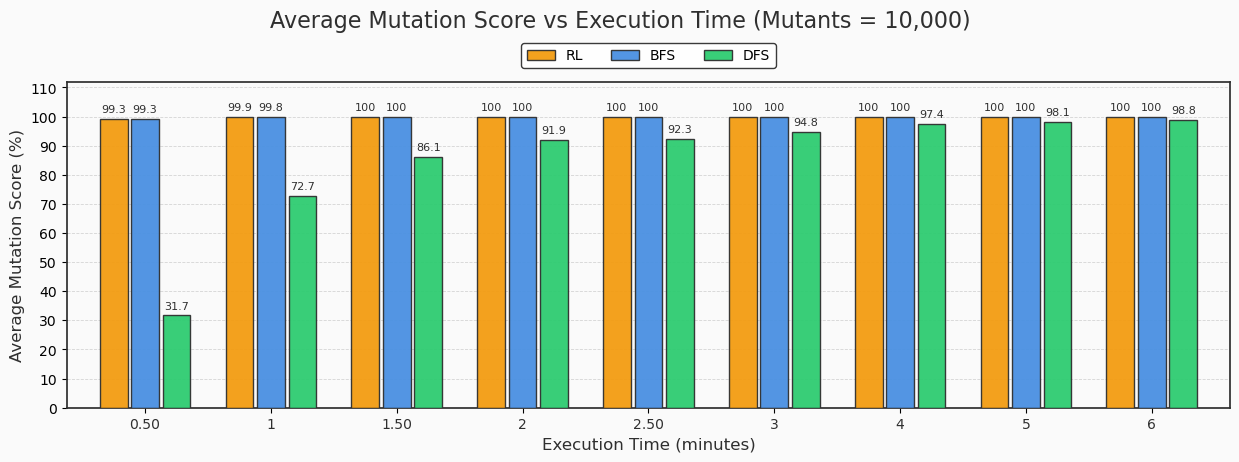

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_10000.png


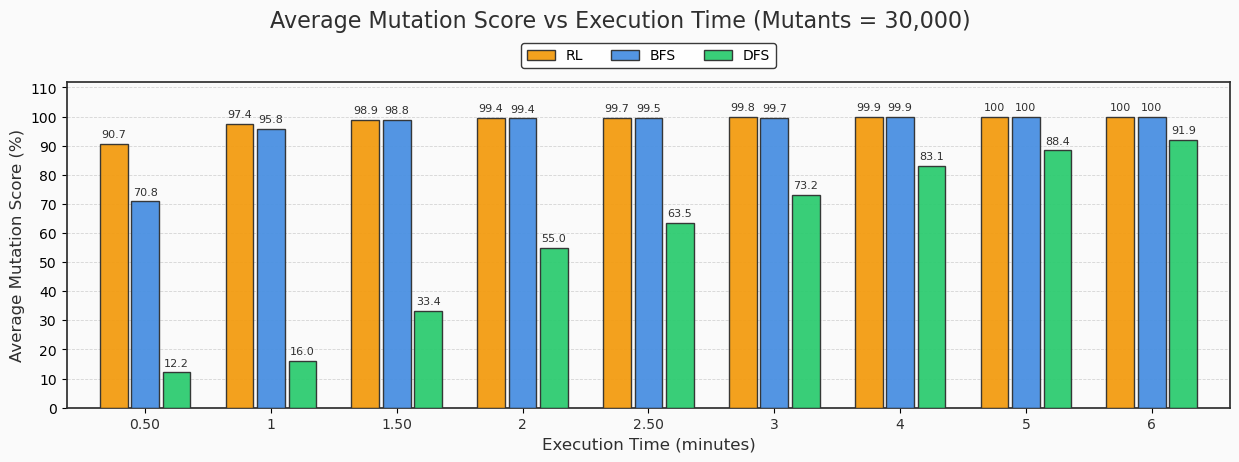

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_30000.png


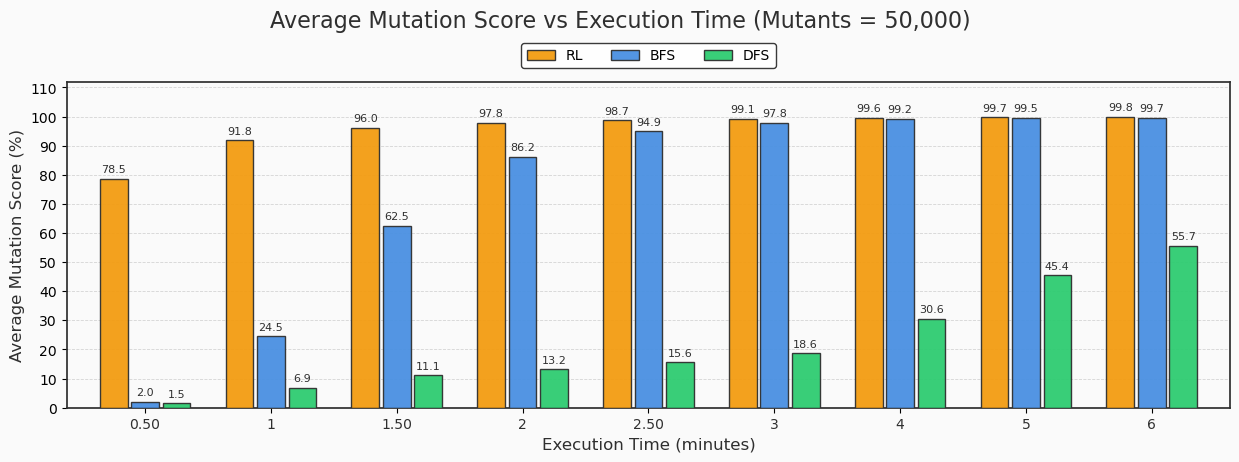

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_50000.png


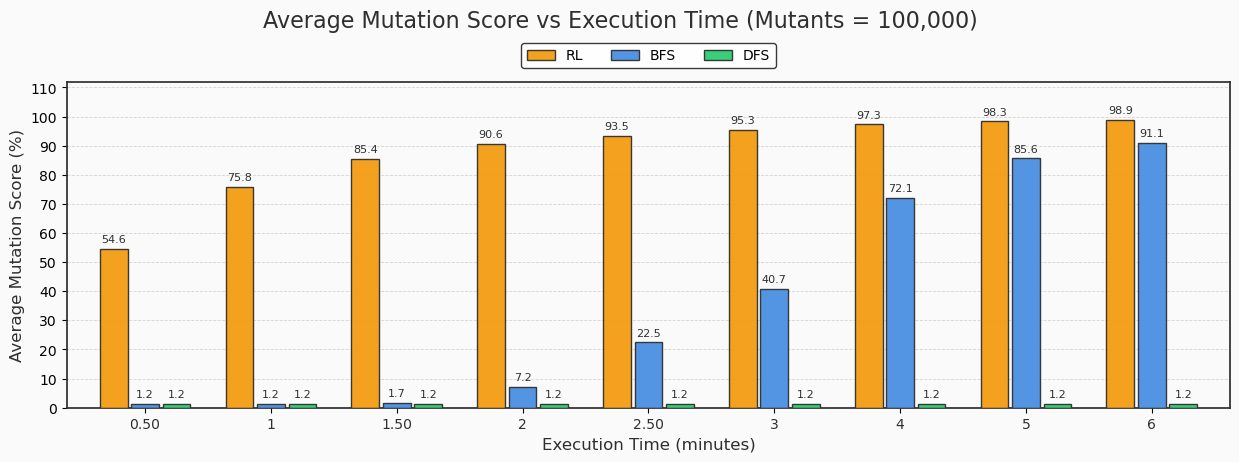

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_100000.png


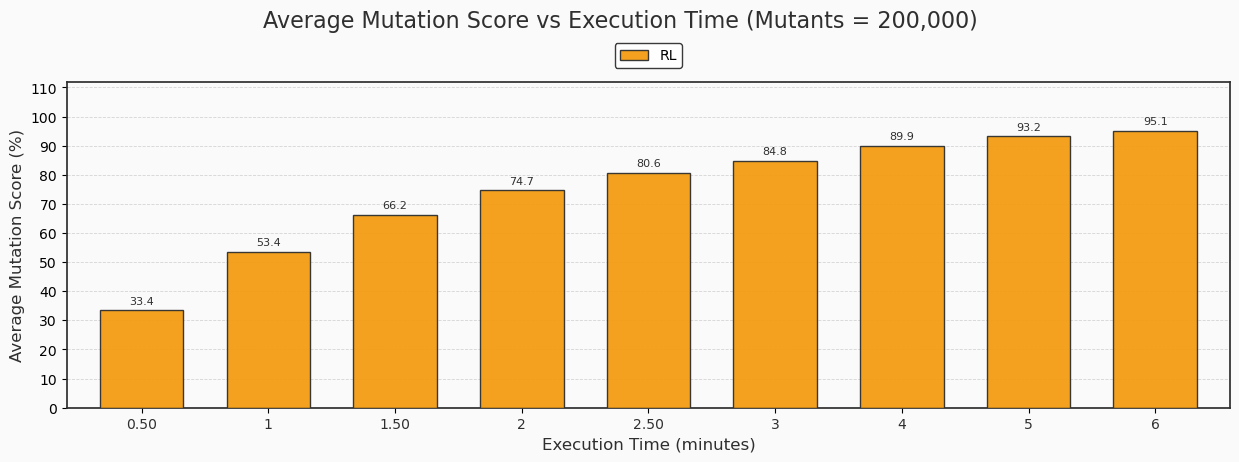

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_mutation_vs_time_bar_200000.png


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ===================== PATH =====================
base_dir = Path('/Users/noshin/Desktop/Dr.Khalid/All Results')

rl_path  = base_dir / 'RL/RL_partial_fsms.xlsx'
bfs_path = base_dir / 'BFS/Combined_BFS_partial.xlsx'
dfs_path = base_dir / 'DFS/Combined_DFS_partial.xlsx'

# ===================== LOAD =====================
rl_df  = pd.read_excel(rl_path);  rl_df["Method"]  = "RL"
bfs_df = pd.read_excel(bfs_path); bfs_df["Method"] = "BFS"
dfs_df = pd.read_excel(dfs_path); dfs_df["Method"] = "DFS"

df = pd.concat([rl_df, bfs_df, dfs_df], ignore_index=True)

# Normalize "Number of Mutants" column name if needed
if "Number of Mutants" not in df.columns:
    for c in df.columns:
        if "Mutant" in c and "Number" in c:
            df.rename(columns={c: "Number of Mutants"}, inplace=True)
            break

# ===================== TIME COLUMN PARSING =====================
score_cols = [c for c in df.columns if re.match(r"^Mutation Score after .* \(%\)$", c)]

def parse_time_to_min(label: str) -> float:
    m = re.search(r"after (.+) \(%\)$", label)
    if not m:
        return None
    t = m.group(1)
    mins = 0.0
    m_min = re.search(r"(\d+)\s*min", t)
    m_sec = re.search(r"(\d+)\s*s", t)
    if m_min:
        mins += float(m_min.group(1))
    if m_sec:
        mins += float(m_sec.group(1)) / 60.0
    if not m_min and not m_sec:
        try:
            mins = float(t)
        except:
            return None
    return mins

time_map = {col: parse_time_to_min(col) for col in score_cols if parse_time_to_min(col) is not None}

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"

# NEW: Updated vibrant, distinct color palette
COLORS = {
    "RL": "#F39C12", # Deep Gold
    "BFS": "#4A90E2", # Professional Blue
    "DFS": "#2ECC71", # Bright Green
}

GROUP_WIDTH = 0.75
ANNOTATE_EVERY = 1

ORDERED_MUTANTS = [10000, 30000, 50000, 100000, 200000]
present_mutants = [m for m in ORDERED_MUTANTS if (df["Number of Mutants"] == m).any()]
if not present_mutants:
    present_mutants = sorted(df["Number of Mutants"].dropna().unique().tolist())

# ===================== PLOT FUNCTION =====================
def make_bar_plot_for_mutants(mutants_value: int):
    sub = df[df["Number of Mutants"] == mutants_value].copy()
    if sub.empty:
        return

    # Aggregate mean mutation score per (method, time)
    rows = []
    for method in sub["Method"].unique():
        subm = sub[sub["Method"] == method]
        for col, tmin in time_map.items():
            if col in subm.columns:
                rows.append([tmin, method, subm[col].mean(skipna=True)])
    plot_df = pd.DataFrame(rows, columns=["Time (min)", "Method", "Avg Mutation Score (%)"])

    # Pivot to (times x methods)
    pivot_df = plot_df.pivot_table(index="Time (min)", columns="Method",
                                values="Avg Mutation Score (%)").sort_index()

    # Force the bar order: RL first
    METHOD_ORDER = ["RL", "BFS", "DFS"]
    # Keep only methods that actually exist in the data
    methods = [m for m in METHOD_ORDER if m in pivot_df.columns]
    pivot_df = pivot_df[methods]

    times = pivot_df.index.values
    x = np.arange(len(times))
    n = len(methods)
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    
    # === CHANGED LINE: Added axis='y' to only show horizontal grid lines ===
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    # === HEADER ===
    fig.suptitle(f"Average Mutation Score vs Execution Time (Mutants = {mutants_value:,})",
                 fontsize=16, color=EDGE, y = 0.88, x = 0.5)

    # === BARS ===
    for i, method in enumerate(methods):
        y = pivot_df[method].values
        positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

        bars = ax.bar(
            positions, y,
            width=bar_width * 0.88,
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3
        )

        # value labels
        for j, b in enumerate(bars):
            if (j % ANNOTATE_EVERY) != 0:
                continue
            h = b.get_height()
            
            # Don't annotate if NaN
            if np.isnan(h):
                continue
                
            text_val = "100" if h >= 99.9 else f"{h:.1f}"
            
            ax.text(b.get_x() + b.get_width()/2, h + 1.5, text_val,
                    ha="center", va="bottom", fontsize=8, color=EDGE)

    # ticks centered under each group
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(t)}" if float(t).is_integer() else f"{t:.2f}" for t in times],
                       fontsize=10, color=EDGE)

    # axes labels & limits
    ax.set_xlabel("Execution Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Mutation Score (%)", fontsize=12, color=EDGE)
    ax.set_yticks(np.arange(0, 111, 10))
    ax.set_ylim(0, 112)

    # frame
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # legend
    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),  
        ncol=n,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = base_dir / f"avg_mutation_vs_time_bar_{mutants_value}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

# ===================== RUN =====================
for m in present_mutants:
    make_bar_plot_for_mutants(m)

Saved: /Users/noshin/Desktop/Dr.Khalid/All Results/Overall_Average_Split_Scale.png


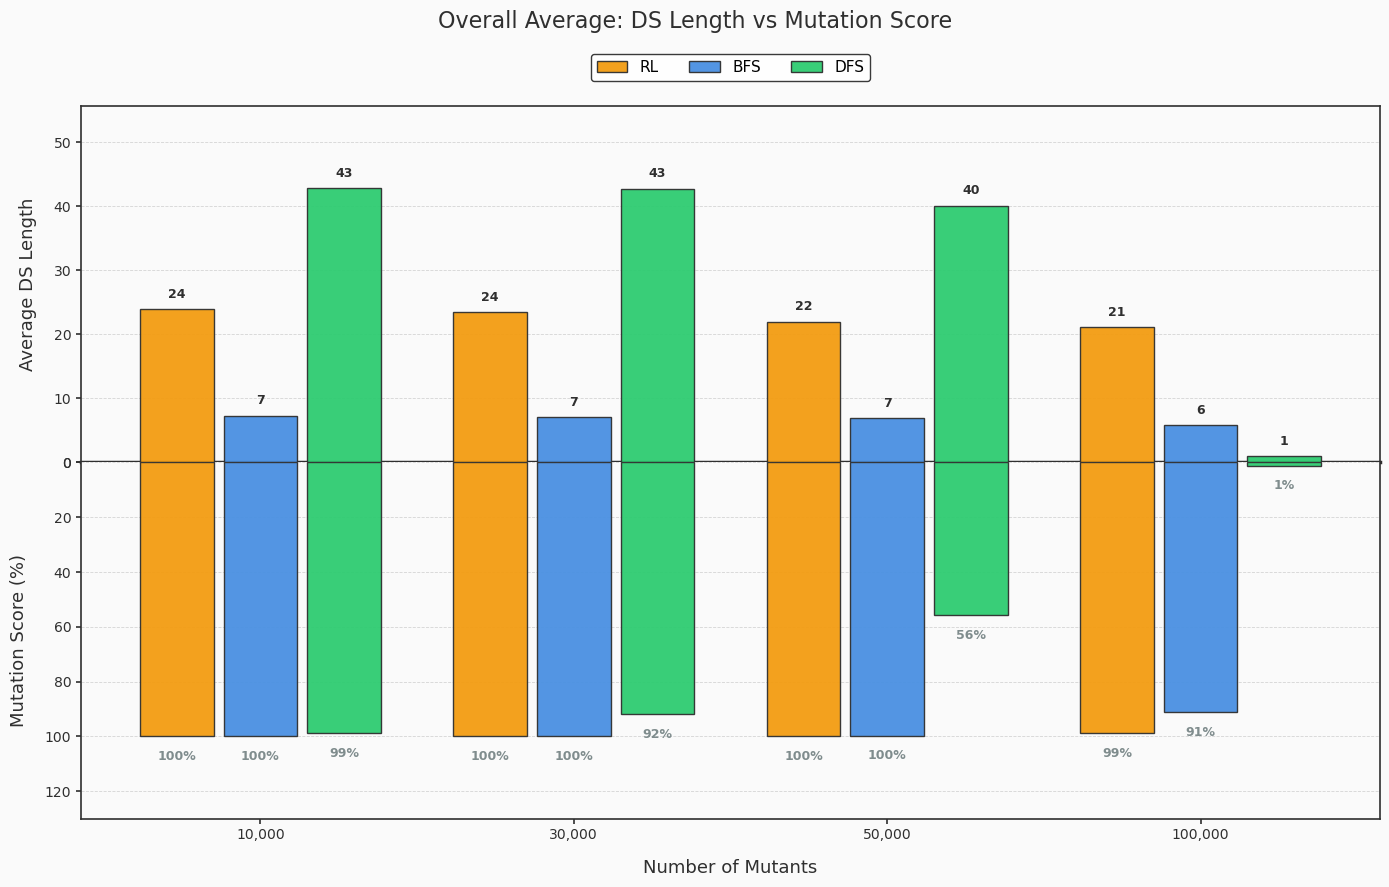

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== PATH =====================
base_dir = Path('/Users/noshin/Desktop/Dr.Khalid/All Results')

rl_path  = base_dir / 'RL/RL_partial_fsms.xlsx'
bfs_path = base_dir / 'BFS/Combined_BFS_partial.xlsx'
dfs_path = base_dir / 'DFS/Combined_DFS_partial.xlsx'

# ===================== LOAD DATA =====================
def load_and_prep(path, method_name):
    try:
        df = pd.read_excel(path)
        
        # Check for columns (we take the final DS Length & Mutation Score at 6 minutes)
        ds_col = "DS Length after 6min"
        ms_col = "Mutation Score after 6min (%)"
        
        # Fallback just in case the 6min column name is slightly different
        if ds_col not in df.columns:
            ds_cols = [c for c in df.columns if "DS Length" in c]
            if ds_cols:
                ds_col = ds_cols[-1]
            else:
                # NEW FALLBACK: Handle RL file which uses "Depth Max Mutants Killed"
                alt_cols = [c for c in df.columns if "Depth Max Mutants Killed" in c]
                if not alt_cols:
                    alt_cols = [c for c in df.columns if "Max Depth Reached" in c]
                
                if alt_cols:
                    ds_col = alt_cols[-1] # Grabs the last one (usually 6min)
                else:
                    print(f"No DS Length or equivalent Depth column found in {method_name}")
                    return pd.DataFrame()
                
        if ms_col not in df.columns:
            ms_cols = [c for c in df.columns if "Mutation Score" in c]
            if ms_cols:
                ms_col = ms_cols[-1]
            else:
                print(f"No Mutation Score column found in {method_name}")
                ms_col = None
                
        # We only need 'Number of Mutants', 'DS Length', and 'Mutation Score'
        cols_to_keep = ["Number of Mutants", ds_col]
        if ms_col: cols_to_keep.append(ms_col)
        
        sub = df[cols_to_keep].copy()
        sub["Method"] = method_name
        
        sub.rename(columns={ds_col: "DS Length"}, inplace=True)
        if ms_col: sub.rename(columns={ms_col: "Mutation Score"}, inplace=True)
        
        return sub
        
    except Exception as e:
        print(f"Warning: Could not load {path}. Error: {e}")
        return pd.DataFrame()

bfs_df = load_and_prep(bfs_path, "BFS")
dfs_df = load_and_prep(dfs_path, "DFS")
rl_df  = load_and_prep(rl_path, "RL")

# Combine all valid dataframes
df = pd.concat([rl_df, bfs_df, dfs_df], ignore_index=True)

if df.empty:
    print("Error: No data loaded. Check paths.")
    exit()

# ===================== FILTER OUT 200k =====================
# Drop the 200,000 mutants BEFORE aggregating the averages
df = df[df["Number of Mutants"] != 200000]

# ===================== AGGREGATE TO AVERAGE =====================
# Average the lengths and scores across the machines for each method and mutant size
agg_ds = df.groupby(["Number of Mutants", "Method"])["DS Length"].mean().unstack().reset_index()
agg_ms = df.groupby(["Number of Mutants", "Method"])["Mutation Score"].mean().unstack().reset_index()

# Ensure all method columns exist even if data is missing
METHOD_ORDER = ["RL", "BFS", "DFS"]
for m in METHOD_ORDER:
    if m not in agg_ds.columns:
        agg_ds[m] = np.nan
    if m not in agg_ms.columns:
        agg_ms[m] = np.nan

# Sort to make sure X-axis is logically ordered
agg_ds = agg_ds.sort_values(by="Number of Mutants")
agg_ms = agg_ms.sort_values(by="Number of Mutants")

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"

COLORS = {
    "RL": "#F39C12",        # Deep Gold
    "BFS": "#4A90E2",       # Professional Blue
    "DFS": "#2ECC71",       # Bright Green
}

GROUP_WIDTH = 0.8

# ===================== PLOT (SPLIT SCALE) =====================
mutants = agg_ds["Number of Mutants"].values
x = np.arange(len(mutants))
bar_width = GROUP_WIDTH / len(METHOD_ORDER)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(14, 9), 
                                        sharex=True, gridspec_kw={'hspace': 0})
fig.patch.set_facecolor(BG)

# Title positioned high up to leave room for the legend
fig.suptitle("Overall Average: DS Length vs Mutation Score", fontsize=16, color=EDGE, y=0.98)

for ax in (ax_top, ax_bottom):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y', zorder=0)
    ax.set_axisbelow(True)

max_ds = agg_ds[METHOD_ORDER].max().max()
max_ms = agg_ms[METHOD_ORDER].max().max()

for i, method in enumerate(METHOD_ORDER):
    y_ds = agg_ds[method].values
    y_ms = agg_ms[method].values
    positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

    # 1. TOP BARS (DS Length - pointing up)
    bars_ds = ax_top.bar(
        positions, y_ds, width=bar_width * 0.88, label=method,
        color=COLORS.get(method, "#CCCCCC"), edgecolor=EDGE,
        linewidth=1, alpha=0.95, zorder=3
    )
    
    # 2. BOTTOM BARS (Mutation Score - pointing down)
    bars_ms = ax_bottom.bar(
        positions, y_ms, width=bar_width * 0.88, 
        color=COLORS.get(method, "#CCCCCC"), edgecolor=EDGE,
        linewidth=1, alpha=0.95, zorder=3
    )

    # === ADD TEXT LABELS ===
    pad_ds = max_ds * 0.03 if pd.notna(max_ds) and max_ds > 0 else 5
    pad_ms = max_ms * 0.05 if pd.notna(max_ms) and max_ms > 0 else 5

    for bar_up, bar_down, ds, ms in zip(bars_ds, bars_ms, y_ds, y_ms):
        if pd.notna(ds):
            ax_top.text(
                bar_up.get_x() + bar_up.get_width() / 2, ds + pad_ds, 
                f"{ds:.0f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=EDGE, zorder=4
            )
            
        if pd.notna(ms):
            ax_bottom.text(
                bar_down.get_x() + bar_down.get_width() / 2, ms + pad_ms, 
                f"{ms:.0f}%",
                ha='center', va='top', fontsize=9, fontweight='bold', color="#7F8C8D", zorder=4
            )

# === AXES, TICKS & SPINES ===
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels([f"{int(m):,}" for m in mutants], fontsize=11, color=EDGE)
ax_bottom.set_xlabel("Number of Mutants", fontsize=13, color=EDGE, labelpad=12)

ax_top.set_ylabel("Average DS Length", fontsize=13, color=EDGE, labelpad=12)
ax_bottom.set_ylabel("Mutation Score (%)", fontsize=13, color=EDGE, labelpad=12)

# Set limits with ~30% headroom for labels
y_max_ds = max_ds * 1.3 if pd.notna(max_ds) and max_ds > 0 else 100
y_max_ms = max_ms * 1.3 if pd.notna(max_ms) and max_ms > 0 else 100

ax_top.set_ylim(0, y_max_ds)
ax_bottom.set_ylim(y_max_ms, 0) # Inverted

# Clean up spines and ticks
for ax in (ax_top, ax_bottom):
    for spine in ax.spines.values():
        spine.set(color=EDGE, linewidth=1.2)
    ax.tick_params(axis='both', colors=EDGE, labelsize=10, width=1.2)

# Emphasize the central dividing line
ax_top.spines['bottom'].set_linewidth(2.5)
ax_bottom.spines['top'].set_visible(False)

# === LEGEND (ON TOP) ===
leg = ax_top.legend(loc="lower center", bbox_to_anchor=(0.5, 1.05), ncol=len(METHOD_ORDER),
                    frameon=True, framealpha=0.95, fancybox=True, fontsize=11)
leg.get_frame().set(edgecolor=EDGE, linewidth=1.0)

# === LAYOUT ===
plt.tight_layout(rect=[0, 0, 1, 0.99])

out_path = base_dir / "Overall_Average_Split_Scale.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()

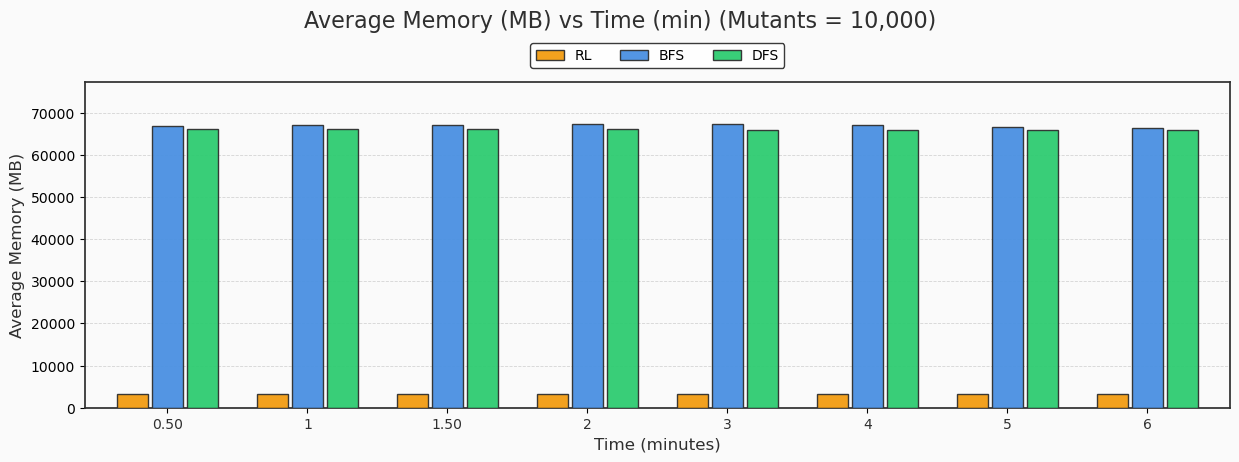

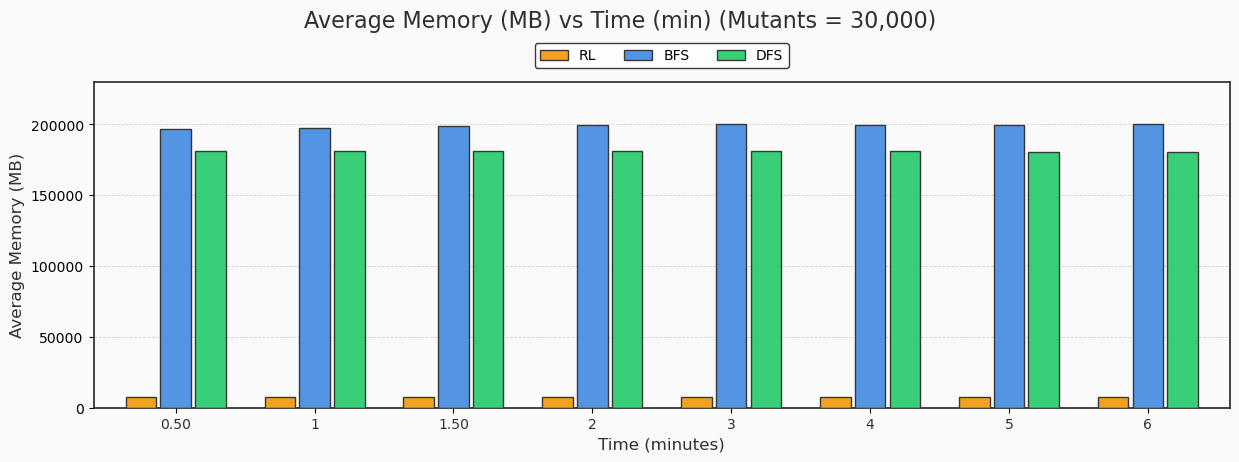

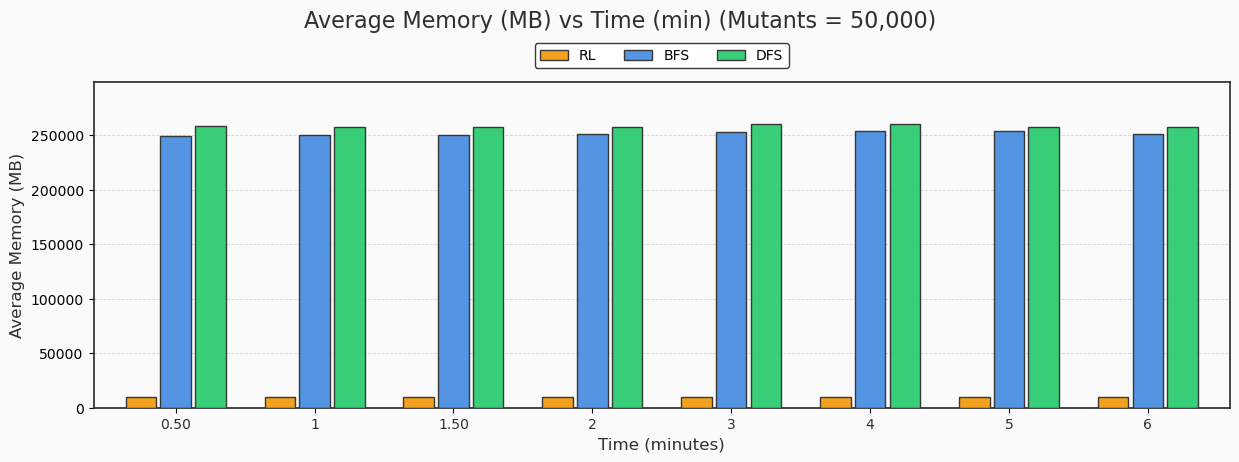

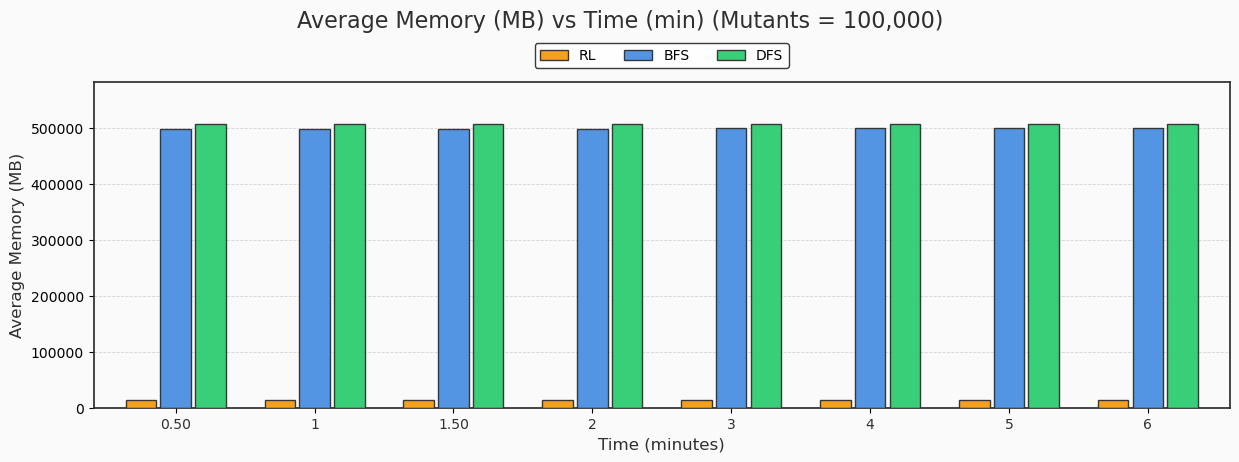

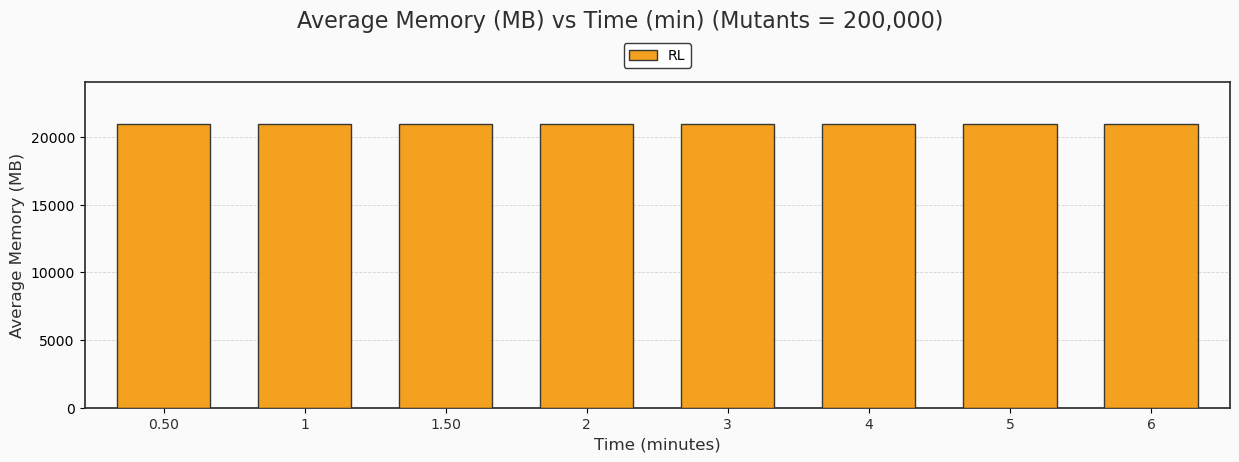

Saved figures:
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_10000.png
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_30000.png
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_50000.png
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_100000.png
- /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_bar_200000.png
Saved data table: /Users/noshin/Desktop/Dr.Khalid/All Results/avg_memory_vs_time_agg.csv


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from typing import Optional, Union

# ===================== PATH =====================
base_dir = Path('/Users/noshin/Desktop/Dr.Khalid/All Results')

rl_path  = base_dir / 'RL/RL_partial_fsms.xlsx'
bfs_path = base_dir / 'BFS/Combined_BFS_partial.xlsx'
dfs_path = base_dir / 'DFS/Combined_DFS_partial.xlsx'

# ===================== LOAD =====================
def load_with_method(path: Path, method: str) -> pd.DataFrame:
    try:
        xl = pd.ExcelFile(path)
        frames = []
        for sh in xl.sheet_names:
            df = xl.parse(sh)
            df["__sheet__"] = sh
            frames.append(df)
        out = pd.concat(frames, ignore_index=True)
        out["Method"] = method
        return out
    except Exception as e:
        print(f"Warning: Could not load {path}. Error: {e}")
        return pd.DataFrame()

rl  = load_with_method(rl_path, "RL")
bfs = load_with_method(bfs_path, "BFS")
dfs = load_with_method(dfs_path, "DFS")

# Combined without BnB
df = pd.concat([rl, bfs, dfs], ignore_index=True)

if df.empty:
    print("Error: No data loaded. Check paths.")
    exit()

# ===================== NORMALIZE "Number of Mutants" =====================
mut_col = None
for c in df.columns:
    cl = str(c).strip().lower()
    if ("mutant" in cl) and ("number" in cl or "count" in cl or cl in {"mutants","num_mutants","n_mutants","no. of mutants"}):
        mut_col = c
        break
if mut_col is None and "Number of Mutants" in df.columns:
    mut_col = "Number of Mutants"
if mut_col is None:
    df["Number of Mutants"] = np.nan
else:
    df.rename(columns={mut_col: "Number of Mutants"}, inplace=True)

# ===================== DETECT MEMORY-AT-TIME COLUMNS =====================
def extract_minutes(colname: str) -> Optional[float]:
    s = colname.lower()
    if ("memory" not in s) or ("after" not in s):
        return None
    m_min = re.search(r"(\d+(?:\.\d+)?)\s*min", s)
    m_sec = re.search(r"(\d+(?:\.\d+)?)\s*s(?![a-z])", s)
    found = False
    minutes = 0.0
    if m_min:
        minutes += float(m_min.group(1)); found = True
    if m_sec:
        minutes += float(m_sec.group(1)) / 60.0; found = True
    if not found:
        try:
            minutes = float(re.search(r"(\d+(?:\.\d+)?)", s).group(1))
            found = True
        except Exception:
            return None
    return minutes

mem_time_cols = {}
for c in df.columns:
    t = extract_minutes(str(c))
    if t is not None:
        mem_time_cols[str(c)] = t

# ===================== FIXED TIME GRID & SNAP =====================
FIXED_TIMES = [0.5, 1, 1.5, 2, 3, 4, 5, 6]  # minutes

def snap_to_grid(x: float, grid=FIXED_TIMES, tol=0.251):  # 15s tolerance
    arr = np.asarray(grid, dtype=float)
    i = np.argmin(np.abs(arr - x))
    if abs(arr[i] - x) <= tol:
        return float(arr[i])
    return np.nan

# ===================== LONG-FORM DATA =====================
rows = []
for _, r in df.iterrows():
    for col, t in mem_time_cols.items():
        mem_val = pd.to_numeric(r.get(col, np.nan), errors="coerce")
        if pd.notna(mem_val):
            tfix = snap_to_grid(t)
            if not np.isnan(tfix):
                rows.append([
                    r.get("Method", None),
                    r.get("Number of Mutants", None),
                    tfix,
                    float(mem_val)
                ])

long = pd.DataFrame(rows, columns=["Method", "Number of Mutants", "Time (min)", "Memory (MB)"])
agg = (long.groupby(["Number of Mutants", "Method", "Time (min)"])["Memory (MB)"]
           .mean()
           .reset_index()
           .sort_values(["Number of Mutants", "Method", "Time (min)"]))

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"

COLORS = {
    "BFS": "#4A90E2", 
    "DFS": "#2ECC71", 
    "RL":  "#F39C12"  
}

GROUP_WIDTH = 0.75         

# ===================== PLOT (ONE FIGURE PER #MUTANTS) =====================
ORDERED_MUTANTS = [10000, 30000, 50000, 100000, 200000]
present_mutants = [m for m in ORDERED_MUTANTS if (agg["Number of Mutants"] == m).any()]
if not present_mutants:
    present_mutants = sorted(pd.unique(agg["Number of Mutants"].dropna()))

def plot_one_bar(mutants_value: Union[int, float]) -> Optional[Path]:
    sub = agg[agg["Number of Mutants"] == mutants_value]
    if sub.empty: return None

    # Pivot the data to get Times as rows and Methods as columns
    pivot_df = sub.pivot_table(index="Time (min)", columns="Method", values="Memory (MB)").reindex(FIXED_TIMES)

    times = pivot_df.index.values
    x = np.arange(len(times))
    
    # CHANGED: Removed Lookahead, RL explicitly first
    ordered_methods = ["RL", "BFS", "DFS"]
    methods = [m for m in ordered_methods if m in pivot_df.columns]
    
    if not methods: 
        methods = list(pivot_df.columns)
        
    n = len(methods)
    if n == 0: return None
    
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    # === HEADER ===
    fig.suptitle(f"Average Memory (MB) vs Time (min) (Mutants = {int(mutants_value):,})",
                 fontsize=16, color=EDGE, y=0.88, x=0.5)

    # === BARS ===
    max_height = 0
    for i, method in enumerate(methods):
        y = pivot_df[method].values
        
        # Track maximum height for setting y-axis limits dynamically
        valid_y = [val for val in y if not np.isnan(val)]
        if valid_y and max(valid_y) > max_height:
            max_height = max(valid_y)

        positions = x - GROUP_WIDTH/2 + (i + 0.5) * bar_width

        ax.bar(
            positions, y,
            width=bar_width * 0.88, # Gap between bars in group
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3
        )

    # === AXES & TICKS ===
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(t)}" if float(t).is_integer() else f"{t:.2f}" for t in times],
                       fontsize=10, color=EDGE)

    ax.set_xlabel("Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Memory (MB)", fontsize=12, color=EDGE)
    
    # Dynamic Y-axis
    ax.set_ylim(0, max_height * 1.15 if max_height > 0 else 100)

    # === FRAME ===
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # === LEGEND ===
    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),  
        ncol=n,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = base_dir / f"avg_memory_vs_time_bar_{int(mutants_value)}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    
    # Shows the plot directly in your Jupyter Notebook
    plt.show() 
    
    return out

# ===================== RUN =====================
saved_paths = []
for m in present_mutants:
    p = plot_one_bar(m)
    if p is not None:
        saved_paths.append(str(p))

print("Saved figures:")
for p in saved_paths:
    print("-", p)

# Export the aggregated table
agg_csv = base_dir / "avg_memory_vs_time_agg.csv"
agg.to_csv(agg_csv, index=False)
print("Saved data table:", agg_csv)

In [96]:
# Scatter plots: Average Memory (MB) vs Time (min), one figure per #mutants
# Uses fixed time grid: [0.5, 1, 1.5, 2, 3, 4, 5, 6]
# Styling and palette per your spec.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ===================== PATH =====================
base_dir = Path("/Users/noshin/Desktop/Dr.Khalid")

bnb_path = base_dir / "All_BnB_results_cery.xlsx"
rl_path  = base_dir / "All_RL_results_cery.xlsx"
bfs_path = base_dir / "Combined_BFS_4n.xlsx"
dfs_path = base_dir / "Combined_DFS_4n.xlsx"

# ===================== LOAD =====================
def load_with_method(path: Path, method: str) -> pd.DataFrame:
    xl = pd.ExcelFile(path)
    frames = []
    for sh in xl.sheet_names:
        df = xl.parse(sh)
        df["__sheet__"] = sh
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["Method"] = method
    return out

bnb = load_with_method(bnb_path, "BnB")
rl  = load_with_method(rl_path, "RL")
bfs = load_with_method(bfs_path, "BFS")
dfs = load_with_method(dfs_path, "DFS")

df = pd.concat([bnb, rl, bfs, dfs], ignore_index=True)

# ===================== NORMALIZE "Number of Mutants" =====================
mut_col = None
for c in df.columns:
    cl = str(c).strip().lower()
    if ("mutant" in cl) and ("number" in cl or "count" in cl or cl in {"mutants","num_mutants","n_mutants","no. of mutants"}):
        mut_col = c
        break
if mut_col is None and "Number of Mutants" in df.columns:
    mut_col = "Number of Mutants"
if mut_col is None:
    # fallback to keep pipeline running if column missing
    df["Number of Mutants"] = np.nan
else:
    df.rename(columns={mut_col: "Number of Mutants"}, inplace=True)

# ===================== DETECT MEMORY-AT-TIME COLUMNS =====================
# Accepts headers like:
# "Memory Usage (MB) after 30s"
# "Memory Usage (MB) after 1min"
# "Memory Usage (MB) after 1min30s"
# "Memory Usage (MB) after 2 min 30 s" (spaces OK)
def extract_minutes(colname: str) -> float | None:
    s = colname.lower()
    if ("memory" not in s) or ("after" not in s):
        return None
    # capture "X min" and "Y s" anywhere
    m_min = re.search(r"(\d+(?:\.\d+)?)\s*min", s)
    m_sec = re.search(r"(\d+(?:\.\d+)?)\s*s(?![a-z])", s)
    found = False
    minutes = 0.0
    if m_min:
        minutes += float(m_min.group(1)); found = True
    if m_sec:
        minutes += float(m_sec.group(1)) / 60.0; found = True
    if not found:
        # bare number fallback -> assume minutes
        try:
            minutes = float(re.search(r"(\d+(?:\.\d+)?)", s).group(1))
            found = True
        except Exception:
            return None
    return minutes

mem_time_cols = {}
for c in df.columns:
    t = extract_minutes(str(c))
    if t is not None:
        mem_time_cols[str(c)] = t

# ===================== FIXED TIME GRID & SNAP =====================
FIXED_TIMES = [0.5, 1, 1.5, 2, 3, 4, 5, 6]  # minutes

def snap_to_grid(x: float, grid=FIXED_TIMES, tol=0.251):  # 15s tolerance
    arr = np.asarray(grid, dtype=float)
    i = np.argmin(np.abs(arr - x))
    if abs(arr[i] - x) <= tol:
        return float(arr[i])
    return np.nan

# ===================== LONG-FORM DATA =====================
rows = []
for _, r in df.iterrows():
    for col, t in mem_time_cols.items():
        mem_val = pd.to_numeric(r.get(col, np.nan), errors="coerce")
        if pd.notna(mem_val):
            tfix = snap_to_grid(t)
            if not np.isnan(tfix):
                rows.append([
                    r.get("Method", None),
                    r.get("Number of Mutants", None),
                    tfix,
                    float(mem_val)
                ])

long = pd.DataFrame(rows, columns=["Method", "Number of Mutants", "Time (min)", "Memory (MB)"])
# Average memory per (mutants, method, time)
agg = (long.groupby(["Number of Mutants", "Method", "Time (min)"])["Memory (MB)"]
           .mean()
           .reset_index()
           .sort_values(["Number of Mutants", "Method", "Time (min)"]))

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"
COLORS = {"BFS": "#6db1ff", "BnB": "#fe7070", "DFS": "#54c45e", "RL": "#ffe342"}
MARKERS = {"BFS": "o", "BnB": "s", "DFS": "^", "RL": "D"}

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.edgecolor": EDGE,
    "axes.linewidth": 1.05,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "grid.linewidth": 0.6,
    "grid.color": GRID,
    "axes.axisbelow": True,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ===================== PLOT (ONE FIGURE PER #MUTANTS) =====================
ORDERED_MUTANTS = [10000, 30000, 50000, 100000, 200000]
present_mutants = [m for m in ORDERED_MUTANTS if (agg["Number of Mutants"] == m).any()]
if not present_mutants:
    present_mutants = sorted(pd.unique(agg["Number of Mutants"].dropna()))

def plot_one(mutants_value: int | float) -> Path | None:
    sub = agg[agg["Number of Mutants"] == mutants_value]
    if sub.empty:
        return None

    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID)
    ax.set_axisbelow(True)

    fig.suptitle(
        f"Average Memory (MB) vs Time (min) — Mutants = {int(mutants_value):,}",
        fontsize=16, color=EDGE, y=0.88, x=0.5
    )

    for method in ["BFS", "BnB", "DFS", "RL"]:
        g = sub[sub["Method"] == method].sort_values("Time (min)")
        if g.empty:
            continue
        ax.plot(
            g["Time (min)"], g["Memory (MB)"],
            marker=MARKERS.get(method, "o"),
            linestyle="-",
            linewidth=1.8,
            markersize=5,
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            markeredgecolor=EDGE,
            markeredgewidth=0.8,
            zorder=3
        )

    # Fixed x-axis ticks
    ax.set_xticks(FIXED_TIMES)
    ax.set_xlim(min(FIXED_TIMES) - 0.2, max(FIXED_TIMES) + 0.2)

    ax.set_xlabel("Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Memory (MB)", fontsize=12, color=EDGE)

    # Frame
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # Legend (top-center)
    methods_present = sub["Method"].unique().tolist()
    ncol = max(len(methods_present), 1)
    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=ncol,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.01, y=0.05)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = base_dir / f"avg_memory_fixed_times_{int(mutants_value)}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return out

saved_paths = []
for m in present_mutants:
    p = plot_one(m)
    if p is not None:
        saved_paths.append(str(p))

print("Saved figures:")
for p in saved_paths:
    print("-", p)

# Optional: also export the aggregated table for verification
agg_csv = base_dir / "avg_memory_vs_time_agg.csv"
agg.to_csv(agg_csv, index=False)
print("Saved data table:", agg_csv)


Saved figures:
- /Users/noshin/Desktop/Dr.Khalid/avg_memory_fixed_times_10000.png
- /Users/noshin/Desktop/Dr.Khalid/avg_memory_fixed_times_30000.png
- /Users/noshin/Desktop/Dr.Khalid/avg_memory_fixed_times_50000.png
- /Users/noshin/Desktop/Dr.Khalid/avg_memory_fixed_times_100000.png
- /Users/noshin/Desktop/Dr.Khalid/avg_memory_fixed_times_200000.png
Saved data table: /Users/noshin/Desktop/Dr.Khalid/avg_memory_vs_time_agg.csv


In [97]:
# Scatter plots: Average DS Length vs Time (min), one figure per #mutants
# Uses fixed time grid: [0.5, 1, 1.5, 2, 3, 4, 5, 6]
# Styling/palette matches previous memory plots.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ===================== PATH =====================
base_dir = Path("/Users/noshin/Desktop/Dr.Khalid")

bnb_path = base_dir / "All_BnB_results_cery.xlsx"
rl_path  = base_dir / "All_RL_results_cery.xlsx"
bfs_path = base_dir / "Combined_BFS_4n.xlsx"
dfs_path = base_dir / "Combined_DFS_4n.xlsx"

# ===================== LOAD =====================
def load_with_method(path: Path, method: str) -> pd.DataFrame:
    xl = pd.ExcelFile(path)
    frames = []
    for sh in xl.sheet_names:
        df = xl.parse(sh)
        df["__sheet__"] = sh
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["Method"] = method
    return out

bnb = load_with_method(bnb_path, "BnB")
rl  = load_with_method(rl_path, "RL")
bfs = load_with_method(bfs_path, "BFS")
dfs = load_with_method(dfs_path, "DFS")

df = pd.concat([bnb, rl, bfs, dfs], ignore_index=True)

# ===================== NORMALIZE "Number of Mutants" =====================
mut_col = None
for c in df.columns:
    cl = str(c).strip().lower()
    if ("mutant" in cl) and ("number" in cl or "count" in cl or cl in {"mutants","num_mutants","n_mutants","no. of mutants"}):
        mut_col = c
        break
if mut_col is None and "Number of Mutants" in df.columns:
    mut_col = "Number of Mutants"
if mut_col is None:
    df["Number of Mutants"] = np.nan
else:
    df.rename(columns={mut_col: "Number of Mutants"}, inplace=True)

# ===================== DETECT DS-LENGTH-AT-TIME COLUMNS =====================
# Match headers like:
# "DS Length after 30s", "DS Length after 1min", "DS Length after 1min30s",
# "DS Length after 2 min 30 s", etc.
def extract_minutes(colname: str) -> float | None:
    s = colname.lower()
    if ("ds length" not in s) or ("after" not in s):
        return None
    m_min = re.search(r"(\d+(?:\.\d+)?)\s*min", s)
    m_sec = re.search(r"(\d+(?:\.\d+)?)\s*s(?![a-z])", s)
    found = False
    minutes = 0.0
    if m_min:
        minutes += float(m_min.group(1)); found = True
    if m_sec:
        minutes += float(m_sec.group(1)) / 60.0; found = True
    if not found:
        try:
            minutes = float(re.search(r"(\d+(?:\.\d+)?)", s).group(1))
            found = True
        except Exception:
            return None
    return minutes

ds_time_cols = {}
for c in df.columns:
    t = extract_minutes(str(c))
    if t is not None:
        ds_time_cols[str(c)] = t

# ===================== FIXED TIME GRID & SNAP =====================
FIXED_TIMES = [0.5, 1, 1.5, 2, 3, 4, 5, 6]  # minutes

def snap_to_grid(x: float, grid=FIXED_TIMES, tol=0.251):  # 15s tolerance
    arr = np.asarray(grid, dtype=float)
    i = np.argmin(np.abs(arr - x))
    if abs(arr[i] - x) <= tol:
        return float(arr[i])
    return np.nan

# ===================== LONG-FORM DATA =====================
rows = []
for _, r in df.iterrows():
    for col, t in ds_time_cols.items():
        val = pd.to_numeric(r.get(col, np.nan), errors="coerce")
        if pd.notna(val):
            tfix = snap_to_grid(t)
            if not np.isnan(tfix):
                rows.append([
                    r.get("Method", None),
                    r.get("Number of Mutants", None),
                    tfix,
                    float(val)
                ])

long = pd.DataFrame(rows, columns=["Method", "Number of Mutants", "Time (min)", "DS Length"])
# Average DS length per (mutants, method, time)
agg = (long.groupby(["Number of Mutants", "Method", "Time (min)"])["DS Length"]
           .mean()
           .reset_index()
           .sort_values(["Number of Mutants", "Method", "Time (min)"]))

# ===================== STYLE =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"
COLORS = {"BFS": "#6db1ff", "BnB": "#fe7070", "DFS": "#54c45e", "RL": "#ffe342"}
MARKERS = {"BFS": "o", "BnB": "s", "DFS": "^", "RL": "D"}

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.edgecolor": EDGE,
    "axes.linewidth": 1.05,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "grid.linewidth": 0.6,
    "grid.color": GRID,
    "axes.axisbelow": True,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ===================== PLOT (ONE FIGURE PER #MUTANTS) =====================
ORDERED_MUTANTS = [10000, 30000, 50000, 100000, 200000]
present_mutants = [m for m in ORDERED_MUTANTS if (agg["Number of Mutants"] == m).any()]
if not present_mutants:
    present_mutants = sorted(pd.unique(agg["Number of Mutants"].dropna()))

def plot_one(mutants_value: int | float) -> Path | None:
    sub = agg[agg["Number of Mutants"] == mutants_value]
    if sub.empty:
        return None

    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID)
    ax.set_axisbelow(True)

    fig.suptitle(
        f"Average DS Length vs Time (min) — Mutants = {int(mutants_value):,}",
        fontsize=16, color=EDGE, y=0.88, x=0.5
    )

    for method in ["BFS", "BnB", "DFS", "RL"]:
        g = sub[sub["Method"] == method].sort_values("Time (min)")
        if g.empty:
            continue
        ax.plot(
            g["Time (min)"], g["DS Length"],
            marker=MARKERS.get(method, "o"),
            linestyle="-",
            linewidth=1.8,
            markersize=5,
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            markeredgecolor=EDGE,
            markeredgewidth=0.8,
            zorder=3
        )

    # Fixed x-axis ticks
    ax.set_xticks(FIXED_TIMES)
    ax.set_xlim(min(FIXED_TIMES) - 0.2, max(FIXED_TIMES) + 0.2)

    ax.set_xlabel("Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average DS Length", fontsize=12, color=EDGE)

    # Frame
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    # Legend (top-center)
    methods_present = sub["Method"].unique().tolist()
    ncol = max(len(methods_present), 1)
    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=ncol,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.01, y=0.05)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = base_dir / f"avg_dslen_fixed_times_{int(mutants_value)}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return out

saved_paths = []
for m in present_mutants:
    p = plot_one(m)
    if p is not None:
        saved_paths.append(str(p))

print("Saved figures:")
for p in saved_paths:
    print("-", p)

# Optional: export aggregated table for verification
agg_csv = base_dir / "avg_dslen_vs_time_agg.csv"
agg.to_csv(agg_csv, index=False)
print("Saved data table:", agg_csv)


Saved figures:
- /Users/noshin/Desktop/Dr.Khalid/avg_dslen_fixed_times_10000.png
- /Users/noshin/Desktop/Dr.Khalid/avg_dslen_fixed_times_30000.png
- /Users/noshin/Desktop/Dr.Khalid/avg_dslen_fixed_times_50000.png
- /Users/noshin/Desktop/Dr.Khalid/avg_dslen_fixed_times_100000.png
- /Users/noshin/Desktop/Dr.Khalid/avg_dslen_fixed_times_200000.png
Saved data table: /Users/noshin/Desktop/Dr.Khalid/avg_dslen_vs_time_agg.csv


---

# New generator — 50,000 mutants

Same four figures as the sections above, same styling, pointed at the 11
workbooks in `results/published/new_generator_50k/`. Self-contained: run the
setup cell, then any figure cell.

**One structural change.** Your originals put **Number of Mutants** on the
x-axis and drew one figure per mutant count. Every run in this batch is 50,000
mutants, so there is no mutant axis left to sweep. The **machine family**
(complete / partial / cerny) takes that slot:

| figure | your original x-axis | here |
|---|---|---|
| Mutation score vs time | time, one fig per mutant count | time, one fig per family |
| Memory vs time | time, one fig per mutant count | time, one fig per family |
| DS length + score panel | mutant count, one fig per machine | machine #, one fig per family |
| Average DS length | mutant count | family |

**Two things to know about the data:**

* **No RL run exists for the partial family** — that group is three bars, not four.
* The RL workbooks spell the checkpoint `1min 30s`; every other workbook spells
  it `1min30s`. The setup cell collapses this. Without it the 1.5 and 2.5 minute
  bars come out half empty.

Figures are written to `results/published/new_generator_50k/figures/` at 300 dpi.

### Setup — paths, load, style

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from typing import Optional, Union

# ===================== PATH =====================
# Resolves whether the notebook runs from notebooks/ or the repo root.
base_dir = None
for _c in (Path("../results/published/new_generator_50k"),
           Path("results/published/new_generator_50k")):
    if _c.is_dir():
        base_dir = _c.resolve()
        break
if base_dir is None:
    raise FileNotFoundError("Set base_dir to the folder holding the 11 workbooks.")

FIG_DIR = base_dir / "figures"
FIG_DIR.mkdir(exist_ok=True)
print(f"Reading from : {base_dir}")
print(f"Figures to   : {FIG_DIR}")

# ===================== FILE MAP =====================
# (Method, Family) -> filename.   NOTE: there is no RL run for the partial family.
FILES = {
    ("BFS", "complete"):       "new_generator_BFS_results_new_generator_128state_fsms_complete_50000.xlsx",
    ("BFS", "partial"):        "new_generator_BFS_results_new_generator_128state_fsms_partial_50000_partial.xlsx",
    ("BFS", "cerny"):          "new_generator_BFS_results_new_generator_cery_machines_50000_cery.xlsx",
    ("DFS", "complete"):       "new_generator_DFS_results_new_generator_128state_fsms_complete_50000.xlsx",
    ("DFS", "partial"):        "new_generator_DFS_results_new_generator_128state_fsms_partial_50000_partial.xlsx",
    ("DFS", "cerny"):          "new_generator_DFS_results_new_generator_cery_machines_50000_cery.xlsx",
    ("Lookahead", "complete"): "new_generator_Lookahead_results_new_generator_128state_fsms_complete_50000.xlsx",
    ("Lookahead", "partial"):  "new_generator_Lookahead_results_new_generator_128state_fsms_partial_50000_partial.xlsx",
    ("Lookahead", "cerny"):    "new_generator_Lookahead_results_new_generator_cery_machines_50000_cery.xlsx",
    ("RL", "complete"):        "new_generator_RL_results_50k.xlsx",
    ("RL", "cerny"):           "new_generator_RL_results_50k_cery.xlsx",
}

FAMILY_ORDER = ["complete", "partial", "cerny"]
FAMILY_LABEL = {
    "complete": "Complete 128-state FSMs",
    "partial":  "Partial 128-state FSMs",
    "cerny":    "Cerny machines",
}


def normalise_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace and collapse '1min 30s' -> '1min30s'.

    Essential, not cosmetic: the RL workbooks use the spaced form and every
    other workbook uses the unspaced one. Without this the two spellings pivot
    into separate columns and the 1.5 / 2.5 minute bars come out half empty.
    """
    mapping = {}
    for c in df.columns:
        s = re.sub(r"(\d+)\s*min\s+(\d+)\s*s", r"\1min\2s", str(c).strip())
        mapping[c] = re.sub(r"\s{2,}", " ", s)
    return df.rename(columns=mapping)


# ===================== LOAD =====================
frames = []
for (method, family), fname in FILES.items():
    path = base_dir / fname
    if not path.exists():
        print(f"  MISSING  {method:<10} {family:<9} {fname}")
        continue
    d = normalise_columns(pd.read_excel(path))
    d["Method"] = method
    d["Family"] = family
    frames.append(d)

df = pd.concat(frames, ignore_index=True)

if "Number of Mutants" not in df.columns:
    for c in df.columns:
        if "Mutant" in c and "Number" in c:
            df.rename(columns={c: "Number of Mutants"}, inplace=True)
            break

# ===================== STYLE (unchanged from your figures) =====================
EDGE = "#2F2F2F"
BG   = "#FAFAFA"
GRID = "gray"

COLORS = {
    "RL":        "#F39C12",   # Deep Gold
    "BFS":       "#4A90E2",   # Professional Blue
    "Lookahead": "#E94E77",   # Soft Crimson
    "DFS":       "#2ECC71",   # Bright Green
}

METHOD_ORDER = ["RL", "BFS", "Lookahead", "DFS"]
GROUP_WIDTH = 0.75
ANNOTATE_EVERY = 1

# ===================== COVERAGE =====================
cov = (df.groupby(["Family", "Method"])["Machine #"].nunique()
         .unstack("Method").reindex(index=FAMILY_ORDER, columns=METHOD_ORDER))
print("\nMachines per family x method (NaN = run not present):")
print(cov.to_string())
print(f"\nMutant counts present: "
      f"{sorted(df['Number of Mutants'].dropna().unique().tolist())}")

### Average Mutation Score vs Execution Time

In [ ]:
# ===================== TIME COLUMN PARSING =====================
score_cols = [c for c in df.columns if re.match(r"^Mutation Score after .* \(%\)$", c)]


def parse_time_to_min(label: str) -> Optional[float]:
    m = re.search(r"after (.+) \(%\)$", label)
    if not m:
        return None
    t = m.group(1)
    mins = 0.0
    m_min = re.search(r"(\d+)\s*min", t)
    m_sec = re.search(r"(\d+)\s*s", t)
    if m_min:
        mins += float(m_min.group(1))
    if m_sec:
        mins += float(m_sec.group(1)) / 60.0
    if not m_min and not m_sec:
        try:
            mins = float(t)
        except Exception:
            return None
    return mins


time_map = {c: parse_time_to_min(c) for c in score_cols
            if parse_time_to_min(c) is not None}


# ===================== PLOT FUNCTION =====================
def make_bar_plot_for_family(family: str):
    sub = df[df["Family"] == family].copy()
    if sub.empty:
        return

    rows = []
    for method in sub["Method"].unique():
        subm = sub[sub["Method"] == method]
        for col, tmin in time_map.items():
            if col in subm.columns:
                rows.append([tmin, method, subm[col].mean(skipna=True)])
    plot_df = pd.DataFrame(rows, columns=["Time (min)", "Method",
                                          "Avg Mutation Score (%)"])

    pivot_df = plot_df.pivot_table(index="Time (min)", columns="Method",
                                   values="Avg Mutation Score (%)").sort_index()

    methods = [m for m in METHOD_ORDER if m in pivot_df.columns]
    pivot_df = pivot_df[methods]

    times = pivot_df.index.values
    x = np.arange(len(times))
    n = len(methods)
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    n_mach = int(sub["Machine #"].nunique())
    fig.suptitle(
        f"Average Mutation Score vs Execution Time — {FAMILY_LABEL[family]} "
        f"(Mutants = 50,000, {n_mach} machines)",
        fontsize=16, color=EDGE, y=0.88, x=0.5)

    # === BARS ===
    for i, method in enumerate(methods):
        y = pivot_df[method].values
        positions = x - GROUP_WIDTH / 2 + (i + 0.5) * bar_width

        bars = ax.bar(
            positions, y,
            width=bar_width * 0.88,
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3,
        )

        for j, b in enumerate(bars):
            if (j % ANNOTATE_EVERY) != 0:
                continue
            h = b.get_height()
            if np.isnan(h):
                continue
            text_val = "100" if h >= 99.9 else f"{h:.1f}"
            ax.text(b.get_x() + b.get_width() / 2, h + 1.5, text_val,
                    ha="center", va="bottom", fontsize=8, color=EDGE)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{int(t)}" if float(t).is_integer() else f"{t:.2f}" for t in times],
        fontsize=10, color=EDGE)

    ax.set_xlabel("Execution Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Mutation Score (%)", fontsize=12, color=EDGE)
    ax.set_yticks(np.arange(0, 111, 10))
    ax.set_ylim(0, 112)

    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=n,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = FIG_DIR / f"avg_mutation_vs_time_bar_{family}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


# ===================== RUN =====================
for fam in FAMILY_ORDER:
    make_bar_plot_for_family(fam)

### Average Memory (MB) vs Time

In [ ]:
# ===================== DETECT MEMORY-AT-TIME COLUMNS =====================
def extract_minutes(colname: str) -> Optional[float]:
    s = colname.lower()
    if ("memory" not in s) or ("after" not in s):
        return None
    m_min = re.search(r"(\d+(?:\.\d+)?)\s*min", s)
    m_sec = re.search(r"(\d+(?:\.\d+)?)\s*s(?![a-z])", s)
    found = False
    minutes = 0.0
    if m_min:
        minutes += float(m_min.group(1)); found = True
    if m_sec:
        minutes += float(m_sec.group(1)) / 60.0; found = True
    if not found:
        try:
            minutes = float(re.search(r"(\d+(?:\.\d+)?)", s).group(1))
            found = True
        except Exception:
            return None
    return minutes


mem_time_cols = {}
for c in df.columns:
    t = extract_minutes(str(c))
    if t is not None:
        mem_time_cols[str(c)] = t

# ===================== FIXED TIME GRID & SNAP =====================
# 2.5 is included: these runs record a 2min30s checkpoint that the older
# Cerny runs did not have.
FIXED_TIMES = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]


def snap_to_grid(x: float, grid=FIXED_TIMES, tol=0.126):
    arr = np.asarray(grid, dtype=float)
    i = np.argmin(np.abs(arr - x))
    if abs(arr[i] - x) <= tol:
        return float(arr[i])
    return np.nan


# ===================== LONG-FORM DATA =====================
rows = []
for _, r in df.iterrows():
    for col, t in mem_time_cols.items():
        mem_val = pd.to_numeric(r.get(col, np.nan), errors="coerce")
        if pd.notna(mem_val):
            tfix = snap_to_grid(t)
            if not np.isnan(tfix):
                rows.append([r.get("Method"), r.get("Family"), tfix, float(mem_val)])

long = pd.DataFrame(rows, columns=["Method", "Family", "Time (min)", "Memory (MB)"])
agg = (long.groupby(["Family", "Method", "Time (min)"])["Memory (MB)"]
           .mean().reset_index()
           .sort_values(["Family", "Method", "Time (min)"]))


# ===================== PLOT (ONE FIGURE PER FAMILY) =====================
def plot_one_bar(family: str) -> Optional[Path]:
    sub = agg[agg["Family"] == family]
    if sub.empty:
        return None

    pivot_df = sub.pivot_table(index="Time (min)", columns="Method",
                               values="Memory (MB)").reindex(FIXED_TIMES)

    times = pivot_df.index.values
    x = np.arange(len(times))

    methods = [m for m in METHOD_ORDER if m in pivot_df.columns]
    if not methods:
        methods = list(pivot_df.columns)
    n = len(methods)
    if n == 0:
        return None
    bar_width = GROUP_WIDTH / n

    # === FIGURE ===
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
    ax.set_axisbelow(True)

    n_mach = int(df[df["Family"] == family]["Machine #"].nunique())
    fig.suptitle(
        f"Average Memory (MB) vs Time (min) — {FAMILY_LABEL[family]} "
        f"(Mutants = 50,000, {n_mach} machines)",
        fontsize=16, color=EDGE, y=0.88, x=0.5)

    # === BARS ===
    max_height = 0
    for i, method in enumerate(methods):
        y = pivot_df[method].values
        valid_y = [v for v in y if not np.isnan(v)]
        if valid_y and max(valid_y) > max_height:
            max_height = max(valid_y)

        positions = x - GROUP_WIDTH / 2 + (i + 0.5) * bar_width
        ax.bar(
            positions, y,
            width=bar_width * 0.88,
            label=method,
            color=COLORS.get(method, "#CCCCCC"),
            edgecolor=EDGE,
            linewidth=1,
            alpha=0.95,
            zorder=3,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{int(t)}" if float(t).is_integer() else f"{t:.2f}" for t in times],
        fontsize=10, color=EDGE)

    ax.set_xlabel("Time (minutes)", fontsize=12, color=EDGE)
    ax.set_ylabel("Average Memory (MB)", fontsize=12, color=EDGE)
    ax.set_ylim(0, max_height * 1.15 if max_height > 0 else 100)

    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color(EDGE)
        s.set_linewidth(1.25)

    leg = ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=n,
        frameon=True,
        framealpha=0.95,
        fancybox=True,
        fontsize=10,
    )
    leg.get_frame().set_edgecolor(EDGE)
    leg.get_frame().set_linewidth(1.0)

    ax.margins(x=0.03)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out = FIG_DIR / f"avg_memory_vs_time_bar_{family}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    return out


# ===================== RUN =====================
saved_paths = []
for fam in FAMILY_ORDER:
    p = plot_one_bar(fam)
    if p is not None:
        saved_paths.append(str(p))

print("Saved figures:")
for p in saved_paths:
    print("-", p)

agg_csv = FIG_DIR / "avg_memory_vs_time_agg.csv"
agg.to_csv(agg_csv, index=False)
print("Saved data table:", agg_csv)

### DS Length vs Mutation Score, per machine

Cerny has 4 machines and fits exactly. Complete and partial have 100 each, so
`MACHINE_LIMIT` caps how many are drawn — raise it or set it to `None` for all.

In [ ]:
# =============================================================================
# Two-panel per-machine figure: DS Length (top) vs Mutation Score (bottom)
# =============================================================================
# Your original put "Number of Mutants" on the x-axis and drew one figure per
# machine — there were 4 Cerny machines and 5 mutant counts. This batch has a
# single mutant count (50,000), so the x-axis becomes "Machine #" and there is
# one figure per family instead.
#
# Cerny has 4 machines and fits exactly. Complete and partial have 100 each, so
# only the first MACHINE_LIMIT are drawn — raise it or set it to None for all.

MACHINE_LIMIT = 20


def load_and_prep(family: str) -> pd.DataFrame:
    sub = df[df["Family"] == family].copy()
    if sub.empty:
        return pd.DataFrame()

    ds_col = "DS Length after 6min"
    ms_col = "Mutation Score after 6min (%)"

    if ds_col not in sub.columns:
        ds_cols = [c for c in sub.columns if "DS Length" in c]
        ds_col = ds_cols[-1] if ds_cols else None
    if ms_col not in sub.columns:
        ms_cols = [c for c in sub.columns if "Mutation Score" in c]
        ms_col = ms_cols[-1] if ms_cols else None
    if not ds_col:
        return pd.DataFrame()

    keep = ["Machine #", "Method", ds_col] + ([ms_col] if ms_col else [])
    out = sub[keep].copy()
    out.rename(columns={ds_col: "DS Length"}, inplace=True)
    if ms_col:
        out.rename(columns={ms_col: "Mutation Score"}, inplace=True)
    return out


for family in FAMILY_ORDER:
    full_df = load_and_prep(family)
    if full_df.empty:
        continue

    machines = sorted(full_df["Machine #"].unique())
    if MACHINE_LIMIT:
        machines = machines[:MACHINE_LIMIT]
    m_df = full_df[full_df["Machine #"].isin(machines)]

    agg_ds = m_df.pivot_table(index="Machine #", columns="Method", values="DS Length")
    agg_ms = m_df.pivot_table(index="Machine #", columns="Method", values="Mutation Score")

    for m in METHOD_ORDER:
        if m not in agg_ds.columns:
            agg_ds[m] = np.nan
        if m not in agg_ms.columns:
            agg_ms[m] = np.nan

    agg_ds = agg_ds.sort_index()
    agg_ms = agg_ms.sort_index()

    x = np.arange(len(agg_ds.index))
    bar_width = 0.8 / len(METHOD_ORDER)

    fig, (ax_top, ax_bottom) = plt.subplots(
        nrows=2, ncols=1, figsize=(14, 8), sharex=True,
        gridspec_kw={'hspace': 0})
    fig.patch.set_facecolor(BG)

    shown = f" (first {len(machines)} of {full_df['Machine #'].nunique()})" \
        if len(machines) < full_df["Machine #"].nunique() else ""
    fig.suptitle(
        f"{FAMILY_LABEL[family]}{shown} — DS Length vs Mutation Score "
        f"at 6 min, 50,000 mutants",
        fontsize=16, color=EDGE)

    for ax in (ax_top, ax_bottom):
        ax.set_facecolor(BG)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')

    for i, method in enumerate(METHOD_ORDER):
        y_ds = agg_ds[method].values
        y_ms = agg_ms[method].values
        positions = x - 0.8 / 2 + (i + 0.5) * bar_width

        bars_ds = ax_top.bar(positions, y_ds, width=bar_width * 0.88,
                             color=COLORS[method], edgecolor=EDGE, label=method)
        bars_ms = ax_bottom.bar(positions, y_ms, width=bar_width * 0.88,
                                color=COLORS[method], edgecolor=EDGE)

        for b_up, b_down, val_ds, val_ms in zip(bars_ds, bars_ms, y_ds, y_ms):
            center_x = b_up.get_x() + b_up.get_width() / 2
            if pd.notna(val_ds):
                ax_top.text(center_x, val_ds + agg_ds.max().max() * 0.02,
                            f"{val_ds:.0f}", ha='center', va='bottom',
                            fontsize=7, fontweight='bold')
            if pd.notna(val_ms):
                ax_bottom.text(center_x, val_ms + 4, f"{val_ms:.0f}%",
                               ha='center', va='top', fontsize=7,
                               fontweight='bold', color="#7F8C8D")

    ax_bottom.set_xticks(x)
    ax_bottom.set_xticklabels([f"{int(m)}" for m in agg_ds.index], fontsize=8)
    ax_bottom.set_xlabel("Machine #", fontsize=12, color=EDGE)
    ax_top.set_ylabel("DS Length")
    ax_bottom.set_ylabel("Mutation Score (%)")

    ax_top.set_ylim(0, np.nanmax(agg_ds.values) * 1.2)
    ax_bottom.set_ylim(115, 0)
    ax_bottom.spines['top'].set_visible(True)
    ax_top.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=4)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    save_path = FIG_DIR / f"{family}_DSLength_vs_Score.png"
    plt.savefig(save_path, dpi=300)
    print(f"Saved: {save_path}")
    plt.show()

### Average DS Length

In [ ]:
# =============================================================================
# Average DS Length — grouped bars
# =============================================================================
# Your original swept "Number of Mutants" on the x-axis. Every run in this
# batch is 50,000 mutants, so the machine family takes that slot instead.

ds_col = "DS Length after 6min"
if ds_col not in df.columns:
    ds_col = [c for c in df.columns if "DS Length" in c][-1]

full_df = df[["Family", "Method", ds_col]].copy()
full_df[ds_col] = pd.to_numeric(full_df[ds_col], errors="coerce")
full_df = full_df.dropna()

agg_df = (full_df.groupby(["Family", "Method"])[ds_col]
                 .mean().unstack().reset_index())

for m in METHOD_ORDER:
    if m not in agg_df.columns:
        agg_df[m] = np.nan

agg_df["Family"] = pd.Categorical(agg_df["Family"], FAMILY_ORDER, ordered=True)
agg_df = agg_df.sort_values("Family")

# ===================== PLOT =====================
families = agg_df["Family"].tolist()
x = np.arange(len(families))
n = len(METHOD_ORDER)
bar_width = GROUP_WIDTH / n

fig, ax = plt.subplots(figsize=(12.5, 5.2))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.grid(True, alpha=0.30, linestyle='--', linewidth=0.6, color=GRID, axis='y')
ax.set_axisbelow(True)

fig.suptitle("Average DS Length at 6 min (Mutants = 50,000)",
             fontsize=16, color=EDGE, y=0.88, x=0.55)

max_height = 0
for i, method in enumerate(METHOD_ORDER):
    y = agg_df[method].values.astype(float)
    valid_y = [v for v in y if not np.isnan(v)]
    if valid_y and max(valid_y) > max_height:
        max_height = max(valid_y)

    positions = x - GROUP_WIDTH / 2 + (i + 0.5) * bar_width
    bars = ax.bar(
        positions, y,
        width=bar_width * 0.88,
        label=method,
        color=COLORS.get(method, "#CCCCCC"),
        edgecolor=EDGE,
        linewidth=1,
        alpha=0.95,
        zorder=3,
    )
    for b, val in zip(bars, y):
        if not np.isnan(val):
            ax.text(b.get_x() + b.get_width() / 2, val, f"{val:,.0f}",
                    ha="center", va="bottom", fontsize=8, color=EDGE)

ax.set_xticks(x)
ax.set_xticklabels([FAMILY_LABEL[f] for f in families], fontsize=10, color=EDGE)

ax.set_xlabel("Machine family", fontsize=12, color=EDGE)
ax.set_ylabel("Average DS Length", fontsize=12, color=EDGE)
ax.set_ylim(0, max_height * 1.15 if max_height > 0 else 100)

for s in ax.spines.values():
    s.set_visible(True)
    s.set_color(EDGE)
    s.set_linewidth(1.25)

leg = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=n,
    frameon=True,
    framealpha=0.95,
    fancybox=True,
    fontsize=10,
)
leg.get_frame().set_edgecolor(EDGE)
leg.get_frame().set_linewidth(1.0)

ax.margins(x=0.03)
plt.tight_layout(rect=[0, 0, 1, 0.92])

out = FIG_DIR / "avg_ds_length_by_family.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")